<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/De_los_ReyesActivity_2_Training_Linear_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 312
Code Title: | Predictive Analytics using Machine Learning
1st Semester | AY 2024-2025
<hr> | <hr>
<u>**ACTIVITY NO.** | **TITLE**
**Name** | De los Reyes, Jann Moises Nyll B.
**Section** | CPE31S3
**Date Performed**: | September 04, 2024
**Date Submitted**: | September 04, 2024
**Instructor**: | Dr. Alonica Villanueva / Engr. Roman M. Richard

<hr>

## 1. Objectives

This activity aims to:
* Perform regression analysis using linear regression and polynomial regression; and
* Solve classification problem using logistic regression.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Demonstrate how to use Python to predic outcome using linear and polynomial regression;
* Demonstrate how to use single and multiple features to predict the outcome using linear regression;
* Demonstrate how to train and predict classification model using logistic regression;
* Evaluate and visualize the performance of different regression models.

## 3. Procedures and Outputs

### 3.1 Setup

These are configurations for running on your local machine. No problem with running it on your colab. This project requires Python 3.7 or above:

In [ ]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [ ]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/training_linear_models` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

### 3.2 Linear Regression

A linear model makes a prediction by simply computing a weighted sum of the input features, plus a constant called the *bias term* or the *intercept term*.

#### 3.2.1 The Normal Equation

In [ ]:
import numpy as np

np.random.seed(42)  # to make this code example reproducible
m = 100  # number of instances
X = 2 * np.random.rand(m, 1)  # column vector
y = 4 + 3 * X + np.random.randn(m, 1)  # column vector

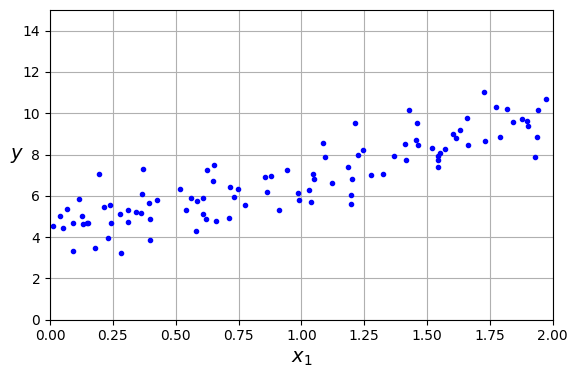

In [ ]:
# extra code – generates and saves Figure 4–1

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("generated_data_plot")
plt.show()

In [ ]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [ ]:
theta_best

array([[4.21509616],
       [2.77011339]])

In [ ]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

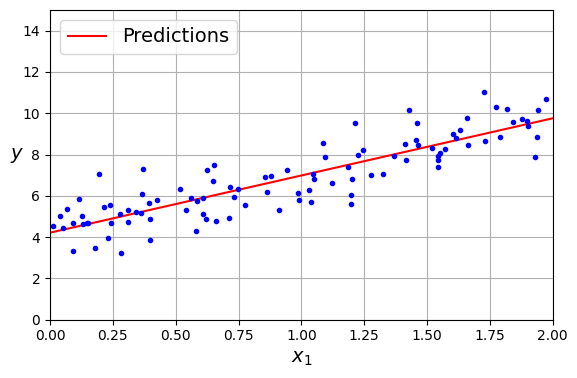

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

# extra code – beautifies and saves Figure 4–2
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
save_fig("linear_model_predictions_plot")

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [ ]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

The `LinearRegression` class is based on the `scipy.linalg.lstsq()` function (the name stands for "least squares"), which you could call directly:

In [ ]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

The pseudoinverse is computed using a standard matrix factorization technique called *Singular Value Decomposition*. What does SVD do? Quickly research and answer.



This function computes $\mathbf{X}^+\mathbf{y}$, where $\mathbf{X}^{+}$ is the _pseudoinverse_ of $\mathbf{X}$ (specifically the Moore-Penrose inverse). You can use `np.linalg.pinv()` to compute the pseudoinverse directly:

In [ ]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

You have multiple methods used to implement the for linear regression. Provide a comparison between the *Singular Value Decomposition* and the Normal Equation Computation. Which is more efficient?

### 3.2 Gradient Descent

Gradient Descent is a very generic optimization algorithm capable of finding optimal solutions to a wide range of problems. Generally, the idea is to tweak parameters iteratively to minimize a cost funtion.

#### 3.2.1 Batch Gradient Descent

To implement Gradient Descent, you need to compute the gradient of the cost func tion with regards to each model parameter θj. In other words, you need to calculate
how much the cost function will change if you change θj
just a little bit. This is called a partial derivative. It is like asking “what is the slope of the mountain under my feet if I face east?” and then asking the same question facing north (and so on for all other dimensions, if you can imagine a universe with more than three dimensions).

In [ ]:
eta = 0.1  # learning rate
n_epochs = 1000
m = len(X_b)  # number of instances

np.random.seed(42)
theta = np.random.randn(2, 1)  # randomly initialized model parameters

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

The trained model parameters:

In [ ]:
theta

array([[4.21509616],
       [2.77011339]])

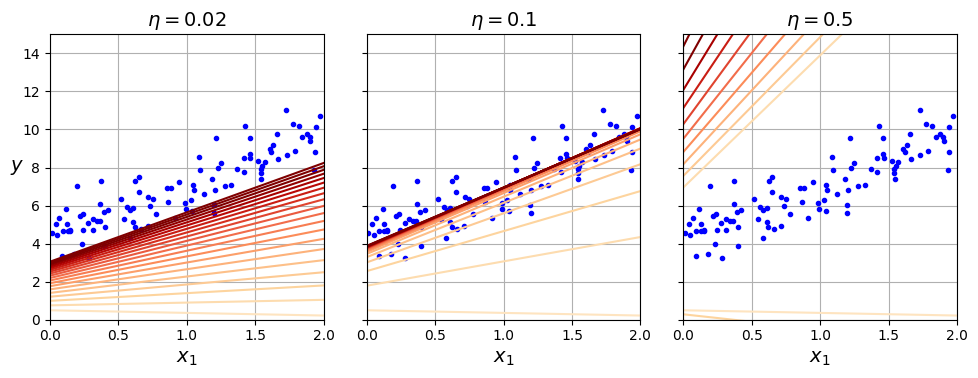

In [ ]:
# extra code – generates and saves Figure 4–8

import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
save_fig("gradient_descent_plot")
plt.show()

Compare the learning rate provided and shown in the graph above. Provide a quick discussion on how learning rate affects model learning based on the given figure.

#### 3.2.2 Stochastic Gradient Descent

The main problem with Batch Gradient Descent is the fact that it uses the whole training set to compute the gradients at every step, which makes it very slow when
the training set is large. At the opposite extreme, Stochastic Gradient Descent just picks a random instance in the training set at every step and computes the gradients
based only on that single instance. Obviously this makes the algorithm much faster since it has very little data to manipulate at every iteration. It also makes it possible to
train on huge training sets, since only one instance needs to be in memory at each iteration (SGD can be implemented as an out-of-core algorithm.)

In [ ]:
theta_path_sgd = []  # extra code – we need to store the path of theta in the
                     #              parameter space to plot the next figure

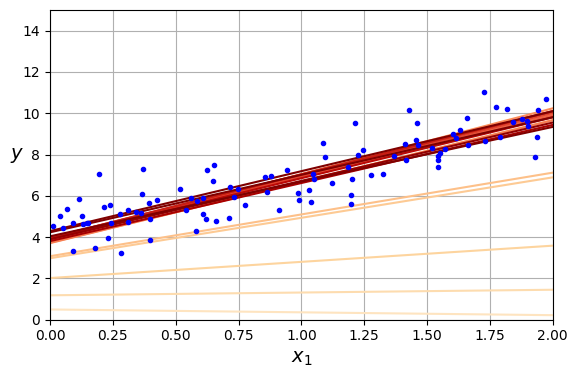

In [ ]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

n_shown = 20  # extra code – just needed to generate the figure below
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting

for epoch in range(n_epochs):
    for iteration in range(m):

        # extra code – these 4 lines are used to generate the figure
        if epoch == 0 and iteration < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
            plt.plot(X_new, y_predict, color=color)

        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)  # extra code – to generate the figure

# extra code – this section beautifies and saves Figure 4–10
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("sgd_plot")
plt.show()

In [ ]:
theta

array([[4.21076011],
       [2.74856079]])

In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets


SGDRegressor(n_iter_no_change=100, penalty=None, random_state=42, tol=1e-05)

In [ ]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

Compare the Stochastic Gradient Descent used in this section to the gradient descent algorithm used previously. What are the benefits to using Stochastic Gradient Descent (SGD)?

#### 3.2.3 Mini-batch gradient descent

The last Gradient Descent algorithm we will look at is called Mini-batch Gradient Descent. It is quite simple to understand once you know Batch and Stochastic Gradient Descent: at each step, instead of computing the gradients based on the full training set (as in Batch GD) or based on just one instance (as in Stochastic GD), Minibatch GD computes the gradients on small random sets of instances called minibatches. The main advantage of Mini-batch GD over Stochastic GD is that you can get a performance boost from hardware optimization of matrix operations, especially
when using GPUs.

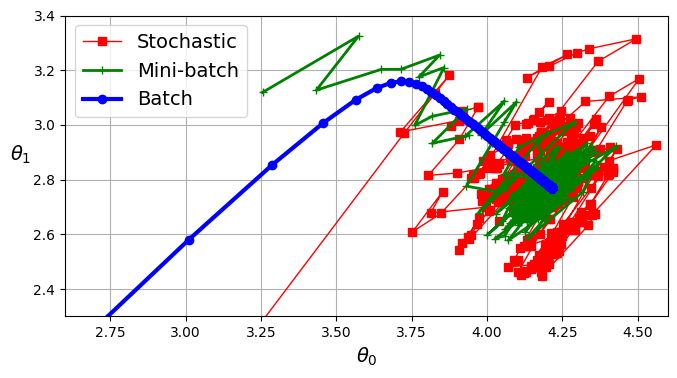

In [ ]:
# extra code – this cell generates and saves Figure 4–11

from math import ceil

n_epochs = 50
minibatch_size = 20
n_batches_per_epoch = ceil(m / minibatch_size)

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

t0, t1 = 200, 1000  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta_path_mgd = []
for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * minibatch_size
        xi = X_b_shuffled[idx : idx + minibatch_size]
        yi = y_shuffled[idx : idx + minibatch_size]
        gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(iteration)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(7, 4))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1,
         label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2,
         label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3,
         label="Batch")
plt.legend(loc="upper left")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$   ", rotation=0)
plt.axis([2.6, 4.6, 2.3, 3.4])
plt.grid()
save_fig("gradient_descent_paths_plot")
plt.show()

Provide a comparison of the 3 gradient descent algorithms included in this section. The comparison must provide an analysis based on different factors such as execution time (among others).

### 3.3 Polynomial Regression

What if your data is actually more complex than a simple straight line? Surprisingly, you can actually use a linear model to fit nonlinear data. A simple way to do this is to
add powers of each feature as new features, then train a linear model on this extended set of features. This technique is called Polynomial Regression.

In [ ]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

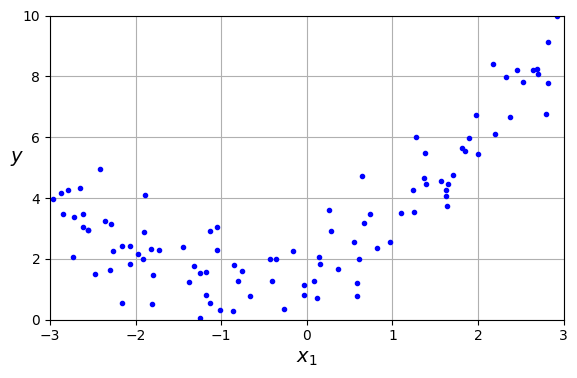

In [ ]:
# extra code – this cell generates and saves Figure 4–12
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("quadratic_data_plot")
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.75275929])

In [ ]:
X_poly[0]

array([-0.75275929,  0.56664654])

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

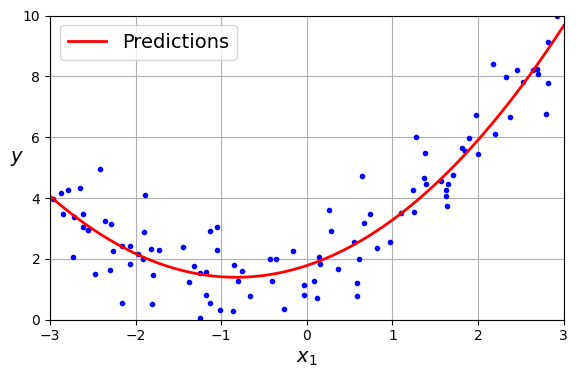

In [ ]:
# extra code – this cell generates and saves Figure 4–13

X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("quadratic_predictions_plot")
plt.show()

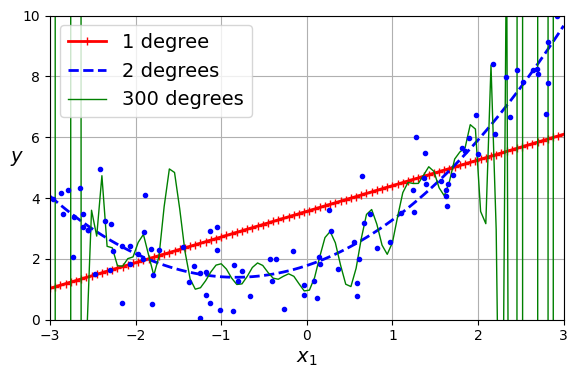

In [ ]:
# extra code – this cell generates and saves Figure 4–14

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(6, 4))

for style, width, degree in (("r-+", 2, 1), ("b--", 2, 2), ("g-", 1, 300)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("high_degree_polynomials_plot")
plt.show()

Based on this example, how is Polynomial Regression able to find relationships between features? Is this something simple Linear Regression is unable to do?

What do we achieve in the figure above? Explain the result of the comparison.

### 3.4 Learning Curves

If you perform high-degree Polynomial Regression, you will likely fit the training data much better than with plain Linear Regression.

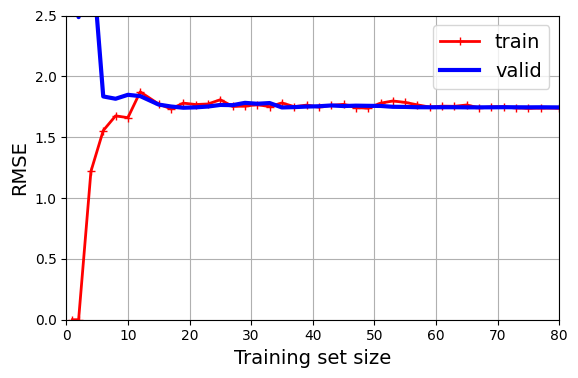

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies and saves Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
save_fig("underfitting_learning_curves_plot")

plt.show()

This deserves a bit of explanation. First, let’s look at the performance on the training data: when there are just one or two instances in the training set, the model can fit
them perfectly, which is why the curve starts at zero. But as new instances are added to the training set, it becomes impossible for the model to fit the training data perfectly, both because the data is noisy and because it is not linear at all. So the error on the training data goes up until it reaches a plateau, at which point adding new instances to the training set doesn’t make the average error much better or worse.


Now let’s look at the performance of the model on the validation data. When the model is trained on very few training instances, it is incapable of generalizing properly, which is why the validation error is initially quite big. Then as the model is shown more training examples, it learns and thus the validation error slowly goes down. However, once again a straight line cannot do a good job modeling the data, so the error ends up at a plateau, very close to the other curve.

What are these learning curves indicating? Is the model overfitting or underfitting? Explain why.

In [ ]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

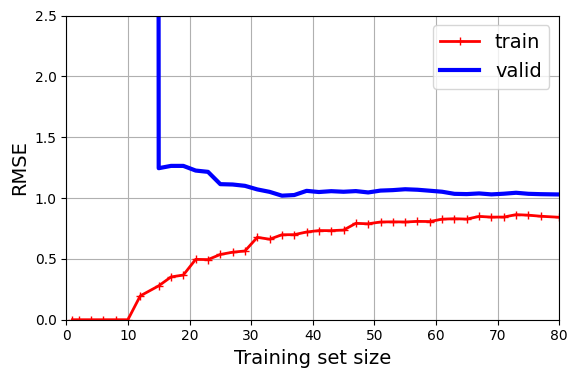

In [ ]:
# extra code – generates and saves Figure 4–16

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 80, 0, 2.5])
save_fig("learning_curves_plot")
plt.show()

Compare this learning curve with the one previously shown above. The major differences you must explain here are as follows:

* The learning rate
* The gap between the curves

### 3.5 Regularized Linear Models

a good way to reduce overfitting is to regularize the model (i.e., to constrain it): the fewer degrees of freedom it has, the harder it will be for it to overfit the data. For example, a simple way to regularize a polynomial model is to reduce the number of polynomial degrees.

#### 3.5.1 Ridge Regression

For a linear model, regularization is typically achieved by constraining the weights of the model. We will now look at Ridge Regression, Lasso Regression, and Elastic Net, which implement three different ways to constrain the weights.

This forces the learning algorithm to not only fit the data but also keep the model weights as small as possible. Note that the regularization term should only be added to the cost function during training. Once the model is trained, you want to evaluate the model’s performance using the unregularized performance measure.

Let's generate a very small and noisy linear dataset:

In [ ]:
# extra code – we've done this type of generation several times before
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

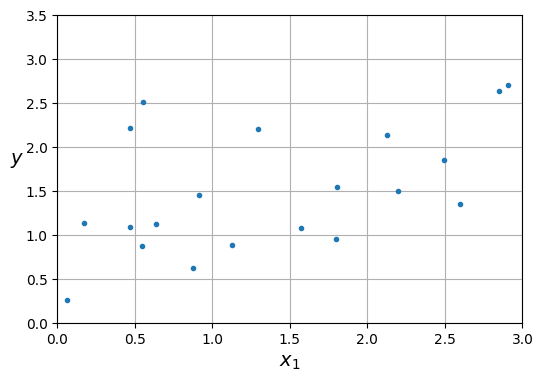

In [ ]:
# extra code – a quick peek at the dataset we just generated
plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [ ]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55325833]])

As with Linear Regression, we can perform Ridge Regression either by computing a closed-form equation or by performing Gradient Descent. The pros and cons are the same.

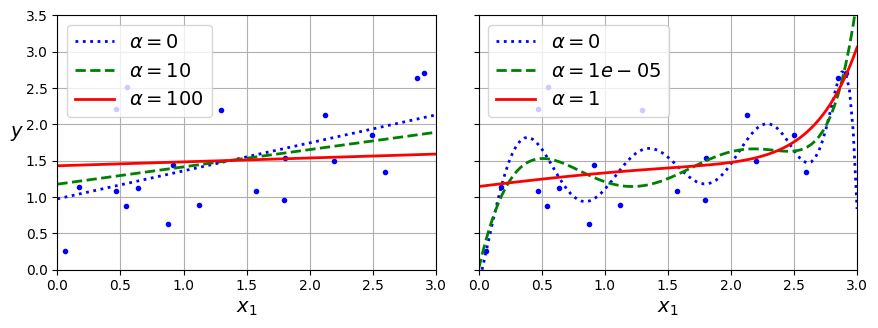

In [ ]:
# extra code – this cell generates and saves Figure 4–17

def plot_model(model_class, polynomial, alphas, **model_kwargs):
    plt.plot(X, y, "b.", linewidth=3)
    for alpha, style in zip(alphas, ("b:", "g--", "r-")):
        if alpha > 0:
            model = model_class(alpha, **model_kwargs)
        else:
            model = LinearRegression()
        if polynomial:
            model = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                model)
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        plt.plot(X_new, y_new_regul, style, linewidth=2,
                 label=fr"$\alpha = {alpha}$")
    plt.legend(loc="upper left")
    plt.xlabel("$x_1$")
    plt.axis([0, 3, 0, 3.5])
    plt.grid()

plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
save_fig("ridge_regression_plot")
plt.show()

In [ ]:
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
                       max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets
sgd_reg.predict([[1.5]])

array([1.55302613])

In [ ]:
# extra code – show that we get roughly the same solution as earlier when
#              we use Stochastic Average GD (solver="sag")
ridge_reg = Ridge(alpha=0.1, solver="sag", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55326019]])

In [ ]:
# extra code – shows the closed form solution of Ridge regression,
#              compare with the next Ridge model's learned parameters below
alpha = 0.1
A = np.array([[0., 0.], [0., 1.]])
X_b = np.c_[np.ones(m), X]
np.linalg.inv(X_b.T @ X_b + alpha * A) @ X_b.T @ y

array([[0.97898394],
       [0.3828496 ]])

In [ ]:
ridge_reg.intercept_, ridge_reg.coef_  # extra code

(array([0.97896386]), array([[0.38286422]]))

Discuss the following:
* What is the purpose of the hyperparameter alpha as seen in the figures above?
* Suppose you are using Ridge Regression and you notice that the training error and the validation error are almost equal and fairly high. Would you say that the model suffers from high bias or high variance? Should you increase the regularization hyperparameter α or reduce it?

#### 3.5.2 Lasso Regression

Least Absolute Shrinkage and Selection Operator Regression (simply called Lasso Regression) is another regularized version of Linear Regression: just like Ridge Regression, it adds a regularization term to the cost function, but it uses the ℓ1 norm of the weight vector instead of half the square of the ℓ2 norm.

In [ ]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([1.53788174])

An important characteristic of Lasso Regression is that it tends to completely eliminate the weights of the least important features (i.e., set them to zero).

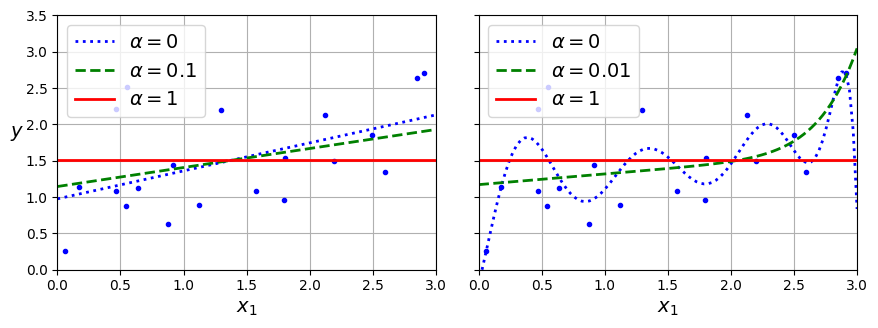

In [ ]:
# extra code – this cell generates and saves Figure 4–18
plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 1e-2, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
save_fig("lasso_regression_plot")
plt.show()

For example, the dashed line in the right plot on Figure 4-18 (with α = 10-7) looks quadratic, almost linear: all the weights for the high-degree polynomial features are equal to zero. In other words, Lasso Regression automatically performs feature selection and outputs a
sparse model (i.e., with few nonzero feature weights).

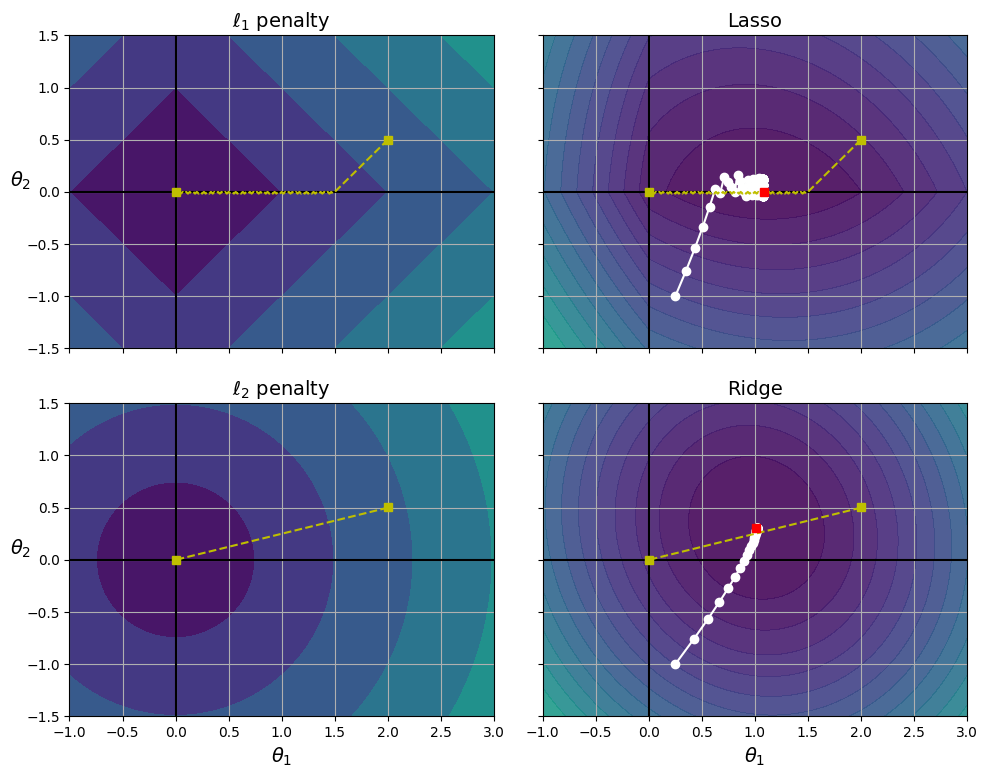

In [ ]:
# extra code – this BIG cell generates and saves Figure 4–19

t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1 / len(Xr) * ((T @ Xr.T - yr.T) ** 2).sum(axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(J.argmin(), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])

def bgd_path(theta, X, y, l1, l2, core=1, eta=0.05, n_iterations=200):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = (core * 2 / len(X) * X.T @ (X @ theta - y)
                     + l1 * np.sign(theta) + l2 * theta)
        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10.1, 8))

for i, N, l1, l2, title in ((0, N1, 2.0, 0, "Lasso"), (1, N2, 0, 2.0, "Ridge")):
    JR = J + l1 * N1 + l2 * 0.5 * N2 ** 2

    tr_min_idx = np.unravel_index(JR.argmin(), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levels = np.exp(np.linspace(0, 1, 20)) - 1
    levelsJ = levels * (J.max() - J.min()) + J.min()
    levelsJR = levels * (JR.max() - JR.min()) + JR.min()
    levelsN = np.linspace(0, N.max(), 10)

    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(theta=np.array([[2.0], [0.5]]), X=Xr, y=yr,
                      l1=np.sign(l1) / 3, l2=np.sign(l2), core=0)
    ax = axes[i, 0]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, N / 2.0, levels=levelsN)
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.set_title(fr"$\ell_{i + 1}$ penalty")
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$", rotation=0)

    ax = axes[i, 1]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    ax.plot(path_JR[:, 0], path_JR[:, 1], "w-o")
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.plot(t1r_min, t2r_min, "rs")
    ax.set_title(title)
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")

save_fig("lasso_vs_ridge_plot")
plt.show()

Using the figure above, compare the Lasso Regression and the Ridge Regression. What kind of performance is observable from the graph?

### 3.6 Early Stopping

A very different way to regularize iterative learning algorithms such as Gradient Descent is to stop training as soon as the validation error reaches a minimum. This is called early stopping.

Let's go back to the quadratic dataset we used earlier:

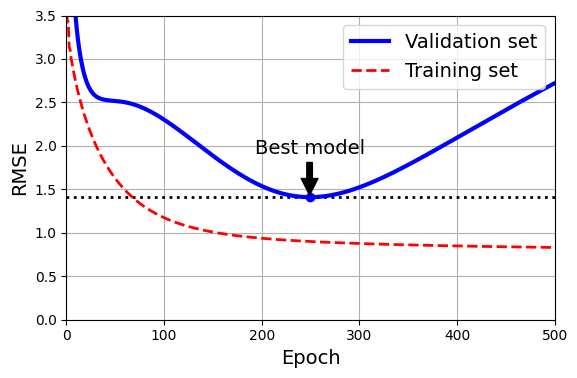

In [ ]:
from copy import deepcopy
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# extra code – creates the same quadratic dataset as earlier and splits it
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []  # extra code – it's for the figure below

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = mean_squared_error(y_valid, y_valid_predict, squared=False)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    # extra code – we evaluate the train error and save it for the figure
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = mean_squared_error(y_train, y_train_predict, squared=False)
    val_errors.append(val_error)
    train_errors.append(train_error)

# extra code – this section generates and saves Figure 4–20
best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate('Best model',
             xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()
save_fig("early_stopping_plot")
plt.show()

Do you foresee any useful benefits of implementing early stopping?

### 3.7 Logistic Regression

Logistic Regression (also called Logit Regression) is com‐
monly used to estimate the probability that an instance belongs to a particular class (e.g., what is the probability that this email is spam?). If the estimated probability is greater than 50%, then the model predicts that the instance belongs to that class (called the positive class, labeled “1”), or else it predicts that it does not (i.e., it belongs to the negative class, labeled “0”). This makes it a binary classifier.

#### 3.7.1 Estimating Probabilities

So how does it work? Just like a Linear Regression model, a Logistic Regression model computes a weighted sum of the input features (plus a bias term), but instead of outputting the result directly like the Linear Regression model does, it outputs the logistic of this result.

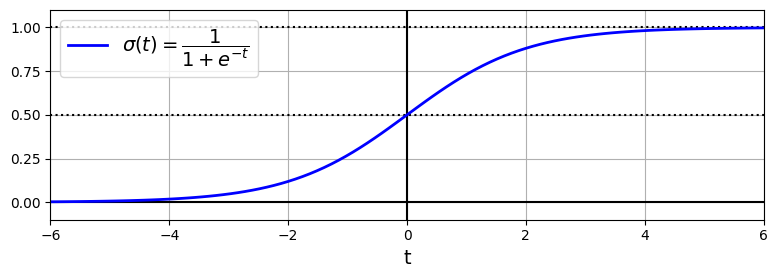

In [ ]:
# extra code – generates and saves Figure 4–21

lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1 + np.exp(-t))

plt.figure(figsize=(8, 3))
plt.plot([-lim, lim], [0, 0], "k-")
plt.plot([-lim, lim], [0.5, 0.5], "k:")
plt.plot([-lim, lim], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \dfrac{1}{1 + e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left")
plt.axis([-lim, lim, -0.1, 1.1])
plt.gca().set_yticks([0, 0.25, 0.5, 0.75, 1])
plt.grid()
save_fig("logistic_function_plot")
plt.show()

Given the figure above, explain how the equation might be interpreted as the figure and how this provides a logistic regression prediction?

#### 3.7.2 Decision Boundaries

Let’s use the iris dataset to illustrate Logistic Regression. This is a famous dataset that contains the sepal and petal length and width of 150 iris flowers of three different species: Iris-Setosa, Iris-Versicolor, and Iris-Virginica

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [ ]:
print(iris.DESCR)  # extra code – it's a bit too long

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [ ]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [ ]:
iris.target.head(3)  # note that the instances are not shuffled

,target
0,0
1,0
2,0


In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

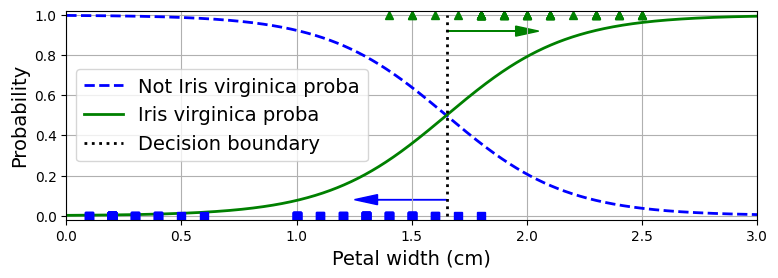

In [ ]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(8, 3))  # extra code – not needed, just formatting
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

# extra code – this section beautifies and saves Figure 4–23
plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()
save_fig("logistic_regression_plot")

plt.show()

In [ ]:
decision_boundary

1.6516516516516517

In [ ]:
log_reg.predict([[1.7], [1.5]])

array([ True, False])

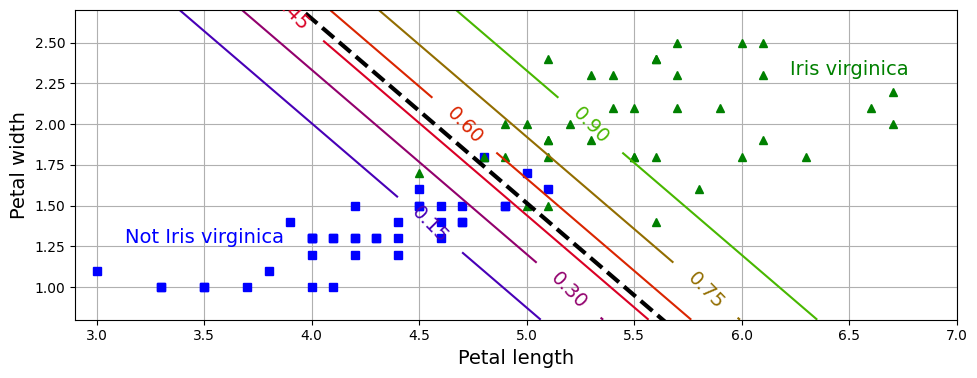

In [ ]:
# extra code – this cell generates and saves Figure 4–24

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(C=2, random_state=42)
log_reg.fit(X_train, y_train)

# for the contour plot
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure
y_proba = log_reg.predict_proba(X_new)
zz = y_proba[:, 1].reshape(x0.shape)

# for the decision boundary
left_right = np.array([2.9, 7])
boundary = -((log_reg.coef_[0, 0] * left_right + log_reg.intercept_[0])
             / log_reg.coef_[0, 1])

plt.figure(figsize=(10, 4))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
plt.clabel(contour, inline=1)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()
save_fig("logistic_regression_contour_plot")
plt.show()

Given the above code and the figure provided, how do l1 and l2 penalties apply to the Logistic regression model?

#### 3.7.3 Softmax Regression

The Logistic Regression model can be generalized to support multiple classes directly, without having to train and combine multiple binary classifiers. This is called Softmax Regression, or Multinomial Logistic Regression.

The idea is quite simple: when given an instance x, the Softmax Regression model first computes a score sk(x) for each class k, then estimates the probability of each
class by applying the somax function (also called the normalized exponential) to the scores. The equation to compute sk(x) should look familiar, as it is just like the equation for Linear Regression prediction

In [ ]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

LogisticRegression(C=30, random_state=42)

In [ ]:
softmax_reg.predict([[5, 2]])

array([2])

In [ ]:
softmax_reg.predict_proba([[5, 2]]).round(2)

array([[0.  , 0.04, 0.96]])

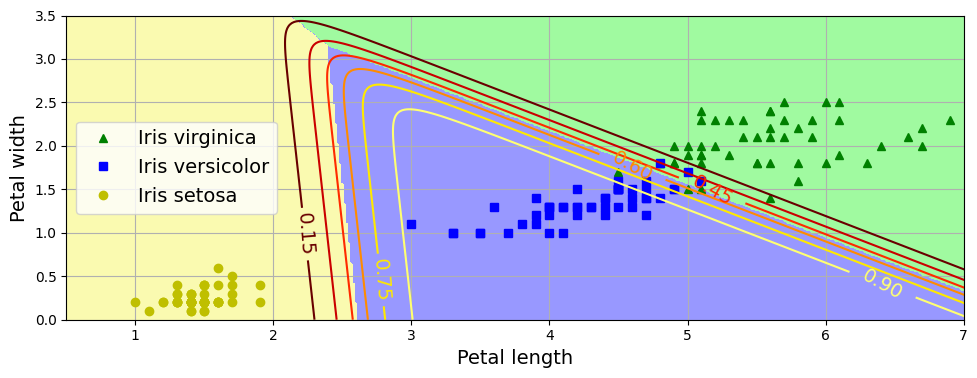

In [ ]:
# extra code – this cell generates and saves Figure 4–25

from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="center left")
plt.axis([0.5, 7, 0, 3.5])
plt.grid()
save_fig("softmax_regression_contour_plot")
plt.show()

Given the code above as an example, how many classes can the Softmax Regression predict? Can it be used to on non-mutually exclusive classes (such as to recognize different faces in a picture)?

## 4. Supplementary Activity

#### 4.1 Linear Regression

* Choose your own dataset





##### **Airfoil Self-Noise**

NASA data set, obtained from a series of aerodynamic and acoustic tests of two and three-dimensional airfoil blade sections conducted in an anechoic wind tunnel. [Airfoil Self-Noise dataset](https://archive.ics.uci.edu/dataset/291/airfoil+self+noise)

The NASA data set comprises different size NACA 0012 airfoils at various wind tunnel speeds and angles of attack. The span of the airfoil and the observer position were the same in all of the experiments.

This dataset has the following features:

Frequency, in Hertz
The angle of attack, in degrees
Chord length, in meters
Free-stream velocity, in meters per second
Suction side displacement thickness, in meters
The only target/label is:

Scaled sound pressure level, in decibels

* Import the dataset


In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
airfoil_self_noise = fetch_ucirepo(id=291)

# data (as pandas dataframes)
X = airfoil_self_noise.data.features
y = airfoil_self_noise.data.targets

# metadata
print(airfoil_self_noise.metadata)

# variable information
print(airfoil_self_noise.variables)


{'uci_id': 291, 'name': 'Airfoil Self-Noise', 'repository_url': 'https://archive.ics.uci.edu/dataset/291/airfoil+self+noise', 'data_url': 'https://archive.ics.uci.edu/static/public/291/data.csv', 'abstract': 'NASA data set, obtained from a series of aerodynamic and acoustic tests of two and three-dimensional airfoil blade sections conducted in an anechoic wind tunnel.', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1503, 'num_features': 5, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['scaled-sound-pressure'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C5VW2C', 'creators': ['Thomas Brooks', 'D. Pope', 'Michael Marcolini'], 'intro_paper': None, 'additional_info': {'summary': 'The NASA data set comprises different size NACA 0012 airfoils at various wind tunnel speeds and angles of

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

asn_df = pd.concat([X,y],axis = 1)
print(f"M = {asn_df.shape[0]} \tN = {asn_df.shape[1]}")
asn_df.head()

M = 1503 	N = 6


,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


* Determine the number of datapoints, columns and data types


In [ ]:
#the number of datapoints
print(asn_df.shape[0])

#the column names
print(asn_df.columns.tolist())

#the data types for each column
print(asn_df.dtypes)

1503
['frequency', 'attack-angle', 'chord-length', 'free-stream-velocity', 'suction-side-displacement-thickness', 'scaled-sound-pressure']
frequency                                int64
attack-angle                           float64
chord-length                           float64
free-stream-velocity                   float64
suction-side-displacement-thickness    float64
scaled-sound-pressure                  float64
dtype: object


* Remove unneccesary columns


In [ ]:
# In this cell, we just remove the 'chord-length' and 'suction-side-displacement-thickness' for sample purposes.
sample_dropcol = asn_df.drop(['chord-length','suction-side-displacement-thickness'], axis = 1)

sample_dropcol.head()

,frequency,attack-angle,free-stream-velocity,scaled-sound-pressure
0,800,0.0,71.3,126.201
1,1000,0.0,71.3,125.201
2,1250,0.0,71.3,125.951
3,1600,0.0,71.3,127.591
4,2000,0.0,71.3,127.461


* Do data cleaning such as removing empty values.


In [ ]:
# We need to check each columns if theres a empty values.
check_empty_val = asn_df.isnull() | asn_df.map(lambda x: x == '')
print(check_empty_val)


      frequency  attack-angle  chord-length  free-stream-velocity  \
0         False         False         False                 False   
1         False         False         False                 False   
2         False         False         False                 False   
3         False         False         False                 False   
4         False         False         False                 False   
...         ...           ...           ...                   ...   
1498      False         False         False                 False   
1499      False         False         False                 False   
1500      False         False         False                 False   
1501      False         False         False                 False   
1502      False         False         False                 False   

      suction-side-displacement-thickness  scaled-sound-pressure  
0                                   False                  False  
1                                   F

In [ ]:
# To remove empty values we can use the dropna() and  to fill it we can use the fillna() method.
check_na = asn_df.isna()
print(check_na)

      frequency  attack-angle  chord-length  free-stream-velocity  \
0         False         False         False                 False   
1         False         False         False                 False   
2         False         False         False                 False   
3         False         False         False                 False   
4         False         False         False                 False   
...         ...           ...           ...                   ...   
1498      False         False         False                 False   
1499      False         False         False                 False   
1500      False         False         False                 False   
1501      False         False         False                 False   
1502      False         False         False                 False   

      suction-side-displacement-thickness  scaled-sound-pressure  
0                                   False                  False  
1                                   F

In [ ]:
# To check duplicates we can use .duplicated() method and drop_duplicates() if  we will remove it.
check_dup = asn_df.duplicated()
print(check_dup)

0       False
1       False
2       False
3       False
4       False
        ...  
1498    False
1499    False
1500    False
1501    False
1502    False
Length: 1503, dtype: bool


As we can see, we do not have missing values in each columns

* Perform descriptive statistics such as mean, median and mode


In [ ]:
asn_df.describe()

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


In [ ]:
# Calculate mean
mean_values = asn_df.mean()

# Calculate median
median_values = asn_df.median()

# Calculate mode
mode_values = asn_df.mode().iloc[0]

print("Mean values:\n", mean_values)
print("\nMedian values:\n", median_values)
print("\nMode values:\n", mode_values)

Mean values:
 frequency                              2886.380572
attack-angle                              6.782302
chord-length                              0.136548
free-stream-velocity                     50.860745
suction-side-displacement-thickness       0.011140
scaled-sound-pressure                   124.835943
dtype: float64

Median values:
 frequency                              1600.000000
attack-angle                              5.400000
chord-length                              0.101600
free-stream-velocity                     39.600000
suction-side-displacement-thickness       0.004957
scaled-sound-pressure                   125.721000
dtype: float64

Mode values:
 frequency                              2000.000000
attack-angle                              0.000000
chord-length                              0.025400
free-stream-velocity                     39.600000
suction-side-displacement-thickness       0.005295
scaled-sound-pressure                   126.540000
Name: 

* Compute the correlation


In [ ]:
correlation_matrix = np.corrcoef(asn_df, rowvar=False)

print("Correlation matrix:\n", correlation_matrix)

Correlation matrix:
 [[ 1.         -0.27276454 -0.00366064  0.13366383 -0.23010735 -0.39071141]
 [-0.27276454  1.         -0.50486815  0.05875957  0.75339378 -0.15610753]
 [-0.00366064 -0.50486815  1.          0.00378663 -0.22084243 -0.23616151]
 [ 0.13366383  0.05875957  0.00378663  1.         -0.00397401  0.1251028 ]
 [-0.23010735  0.75339378 -0.22084243 -0.00397401  1.         -0.31266951]
 [-0.39071141 -0.15610753 -0.23616151  0.1251028  -0.31266951  1.        ]]


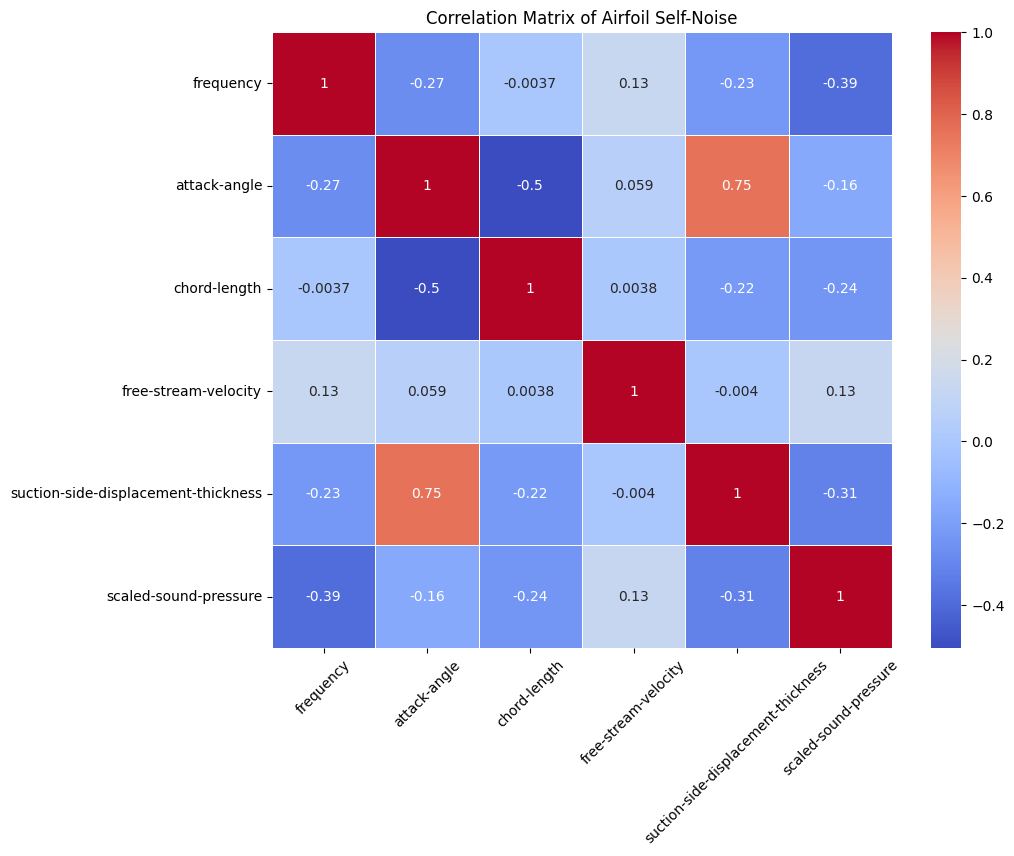

In [ ]:
asn_corr = asn_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(asn_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Airfoil Self-Noise')
plt.xticks(rotation = 45)
plt.show()

* Use One-hot encoding in categorical features


In [ ]:
'''
We dont have categorical features in our dataset, does we dont need to make one
 For reference, pandas library provide a function called 'get_dummies' to perform one-hot encoding

 # One-hot encoding
  df_encoded = pd.get_dummies(df, columns=['Category'])
  print(df_encoded)

The OneHotEncoder class from scikit-learn can also be used for one-hot encoding.
  from sklearn.preprocessing import OneHotEncoder

  # Sample DataFrame
  data = {'Category': ['A', 'B', 'A', 'C']}
  df = pd.DataFrame(data)

  # Initialize OneHotEncoder
  encoder = OneHotEncoder(sparse_output=False)

  # Fit and transform the data
  encoded_data = encoder.fit_transform(df[['Category']])

  # Convert to DataFrame for better readability
  encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Category']))
  print(encoded_df)

'''



* Apply feature scaling


In [ ]:
'''
Feature scaling is an essential preprocessing step in machine learning that involves
adjusting the scale of features to a common range

1.) Standardization scales the data so that it has a mean of 0 and a standard deviation of 1.
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Sample DataFrame
data = {'Feature1': [10, 20, 30, 40], 'Feature2': [100, 200, 300, 400]}
df = pd.DataFrame(data)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the data
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
print(scaled_df)

2.)Min-Max Scaling scales the data to a fixed range, usually [0, 1].
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
print(scaled_df)



* Perform linear regression using one independent variable only using numpy


Text(0, 0.5, '$Scaled-sound-pressure$')

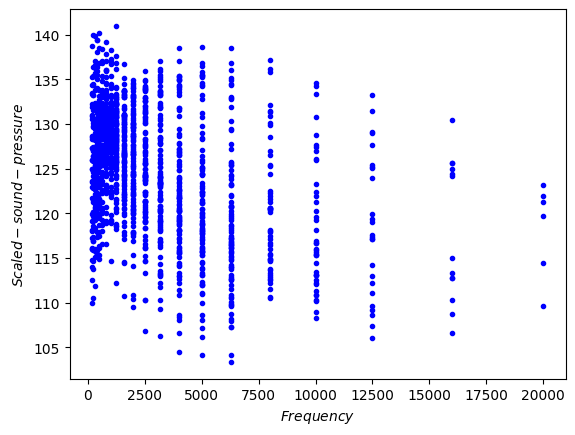

In [ ]:
X_asn1 = asn_df['frequency'].values
y_asn1 = asn_df['scaled-sound-pressure'].values
plt.plot(X_asn1, y_asn1, "b.")
plt.xlabel("$Frequency$")
plt.ylabel("$Scaled-sound-pressure$", rotation=90)

In [ ]:
X_asn1 = np.vstack((np.ones(len(X_asn1)), X_asn1)).T
#Add a column of ones to X to account for the intercept (bias):

In [ ]:
# Calculate the coefficients (theta)
theta = np.linalg.inv(X_asn1.T @ X_asn1) @ X_asn1.T @ y_asn1

# Extract the intercept and slope
intercept, slope = theta
print(f"Intercept: {intercept}, Slope: {slope}")

Intercept: 127.3037375924867, Slope: -0.0008549790125252968


In [ ]:
y_pred1 = X_asn1 @ theta

# Print the first few predictions
print("Predicted values:\n", y_pred1[:5])

Predicted values:
 [126.61975438 126.44875858 126.23501383 125.93577117 125.59377957]


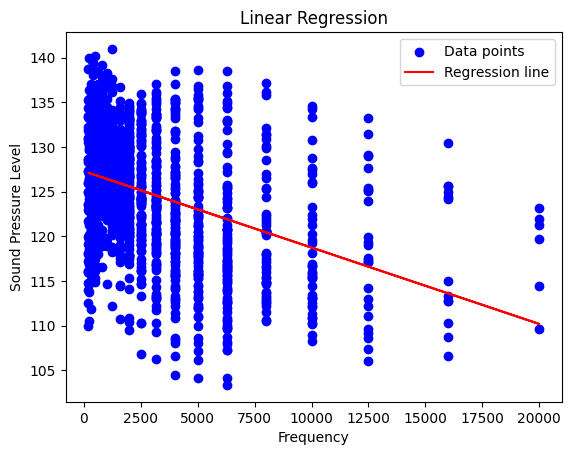

In [ ]:

# Plot the data points
plt.scatter(asn_df["frequency"], asn_df["scaled-sound-pressure"], color='blue', label='Data points')

# Plot the regression line
plt.plot(asn_df["frequency"], y_pred1, color='red', label='Regression line')

plt.xlabel('Frequency')
plt.ylabel('Sound Pressure Level')
plt.title('Linear Regression')
plt.legend()
plt.show()


* Perform linear regression using multiple independent variable using statsmodel


In [ ]:
X_asn2 = asn_df.drop(['scaled-sound-pressure'],axis =1)
y_asn2 = asn_df['scaled-sound-pressure']

In [ ]:
import statsmodels.api as sm

# Add a constant to the independent variables
X_asn2 = sm.add_constant(X_asn2)


In [ ]:
# Fit the model
model = sm.OLS(y_asn2, X_asn2).fit()

# Print the summary of the model
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     scaled-sound-pressure   R-squared:                       0.516
Model:                               OLS   Adj. R-squared:                  0.514
Method:                    Least Squares   F-statistic:                     318.8
Date:                   Fri, 06 Sep 2024   Prob (F-statistic):          1.15e-232
Time:                           13:42:59   Log-Likelihood:                -4490.1
No. Observations:                   1503   AIC:                             8992.
Df Residuals:                       1497   BIC:                             9024.
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

* Perform linear regression using sklearn

In [ ]:
# Spliting the data into 80% for training and 20% for test
X_asn3 = asn_df.drop(['scaled-sound-pressure'],axis =1)
y_asn3 = asn_df['scaled-sound-pressure']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_asn3, y_asn3,test_size=0.20)

from sklearn.linear_model import LinearRegression
m = LinearRegression()
m = m.fit(X_train, y_train)
y_pred = m.predict(X_test)

from sklearn.metrics import mean_squared_error,mean_absolute_error
print('The mean square error is {0:.4f}'.format(mean_squared_error(y_test,y_pred)))
print('The root of mean square error is {0:.4f}'.format(mean_squared_error(y_test,y_pred,squared = False)))
print('The mean absolute error is {0:.4f}'.format(mean_absolute_error(y_test,y_pred)))

The mean square error is 21.9053
The root of mean square error is 4.6803
The mean absolute error is 3.7259


#### 4.2 Polynomial Regression

* Choose your own dataset




##### Manufacturing Data Report

**I. Introduction**

This report presents an analysis of a manufacturing dataset, which simulates real-world data collected from a manufacturing process. The dataset is designed to explore the relationships between various process parameters and product quality. It contains both feature variables that represent process conditions and a target variable that represents the quality rating of the manufactured items. [Manufacturing dataset](https://www.kaggle.com/datasets/rukenmissonnier/manufacturing-data-for-polynomial-regression?resource=download)

**II. Dataset Description**

The manufacturing dataset consists of the following columns:

1. Temperature (°C): This column represents the temperature during the manufacturing process, measured in degrees Celsius. Temperature plays a critical role in many manufacturing processes, influencing material properties and product quality.

2. Pressure (kPa): The pressure applied during the manufacturing process, measured in kilopascals (kPa). Pressure can affect the material transformation and the overall outcome of the manufacturing process.

3. Temperature x Pressure: This feature is an interaction term between temperature and pressure, which captures the combined effect of these two process parameters.

4. Material Fusion Metric: A derived metric calculated as the sum of the square of temperature and the cube of pressure. It represents a material fusion-related measurement during the manufacturing process.

5. Material Transformation Metric: Another derived metric calculated as the cube of temperature minus the square of pressure. It provides insight into material transformation dynamics.

6. Quality Rating: The target variable, 'Quality Rating,' represents the overall quality rating of the produced items. Quality is a crucial aspect of manufacturing, and this rating serves as a measure of the final product's quality.

* Import the dataset


In [ ]:
man_df = pd.read_csv ("/content/manufacturing.csv")
man_df.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [ ]:
# ANSI escape code for bold text
bold = "\033[1m"
reset = "\033[0m"
# Display basic information about the dataset
print(f"{bold}Dataset Info:{reset}")
print("--------------------------------------------------")
print("This section provides an overview of the dataset.")
print("It shows the data types and non-null counts for each column.")
print(man_df.info())

# Display summary statistics of numerical columns
print(f"\n{bold}Summary Statistics:{reset}")
print("--------------------------------------------------")
print("This section provides summary statistics for numerical columns.")
print("It includes metrics like mean, standard deviation, minimum, and maximum values.")
print(man_df.describe())



Dataset Info:
--------------------------------------------------
This section provides an overview of the dataset.
It shows the data types and non-null counts for each column.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB
None

Summary Statistics:
--------------------------------------------------
This section provides summary statistics for numerical columns.
It includes metrics like mean, standard deviati

In [ ]:
# Check for missing values
print(f"\n{bold}Missing Values:{reset}")
print("--------------------------------------------------")
print("This section checks if there are any missing values in the dataset.")
print("It shows the count of missing values for each column.")
print(man_df.isnull().sum())




Missing Values:
--------------------------------------------------
This section checks if there are any missing values in the dataset.
It shows the count of missing values for each column.
Temperature (°C)                  0
Pressure (kPa)                    0
Temperature x Pressure            0
Material Fusion Metric            0
Material Transformation Metric    0
Quality Rating                    0
dtype: int64



Pairplots:
--------------------------------------------------
Pairplots are used to visualize relationships between numerical variables.
Each plot compares two variables, and the diagonal displays histograms.


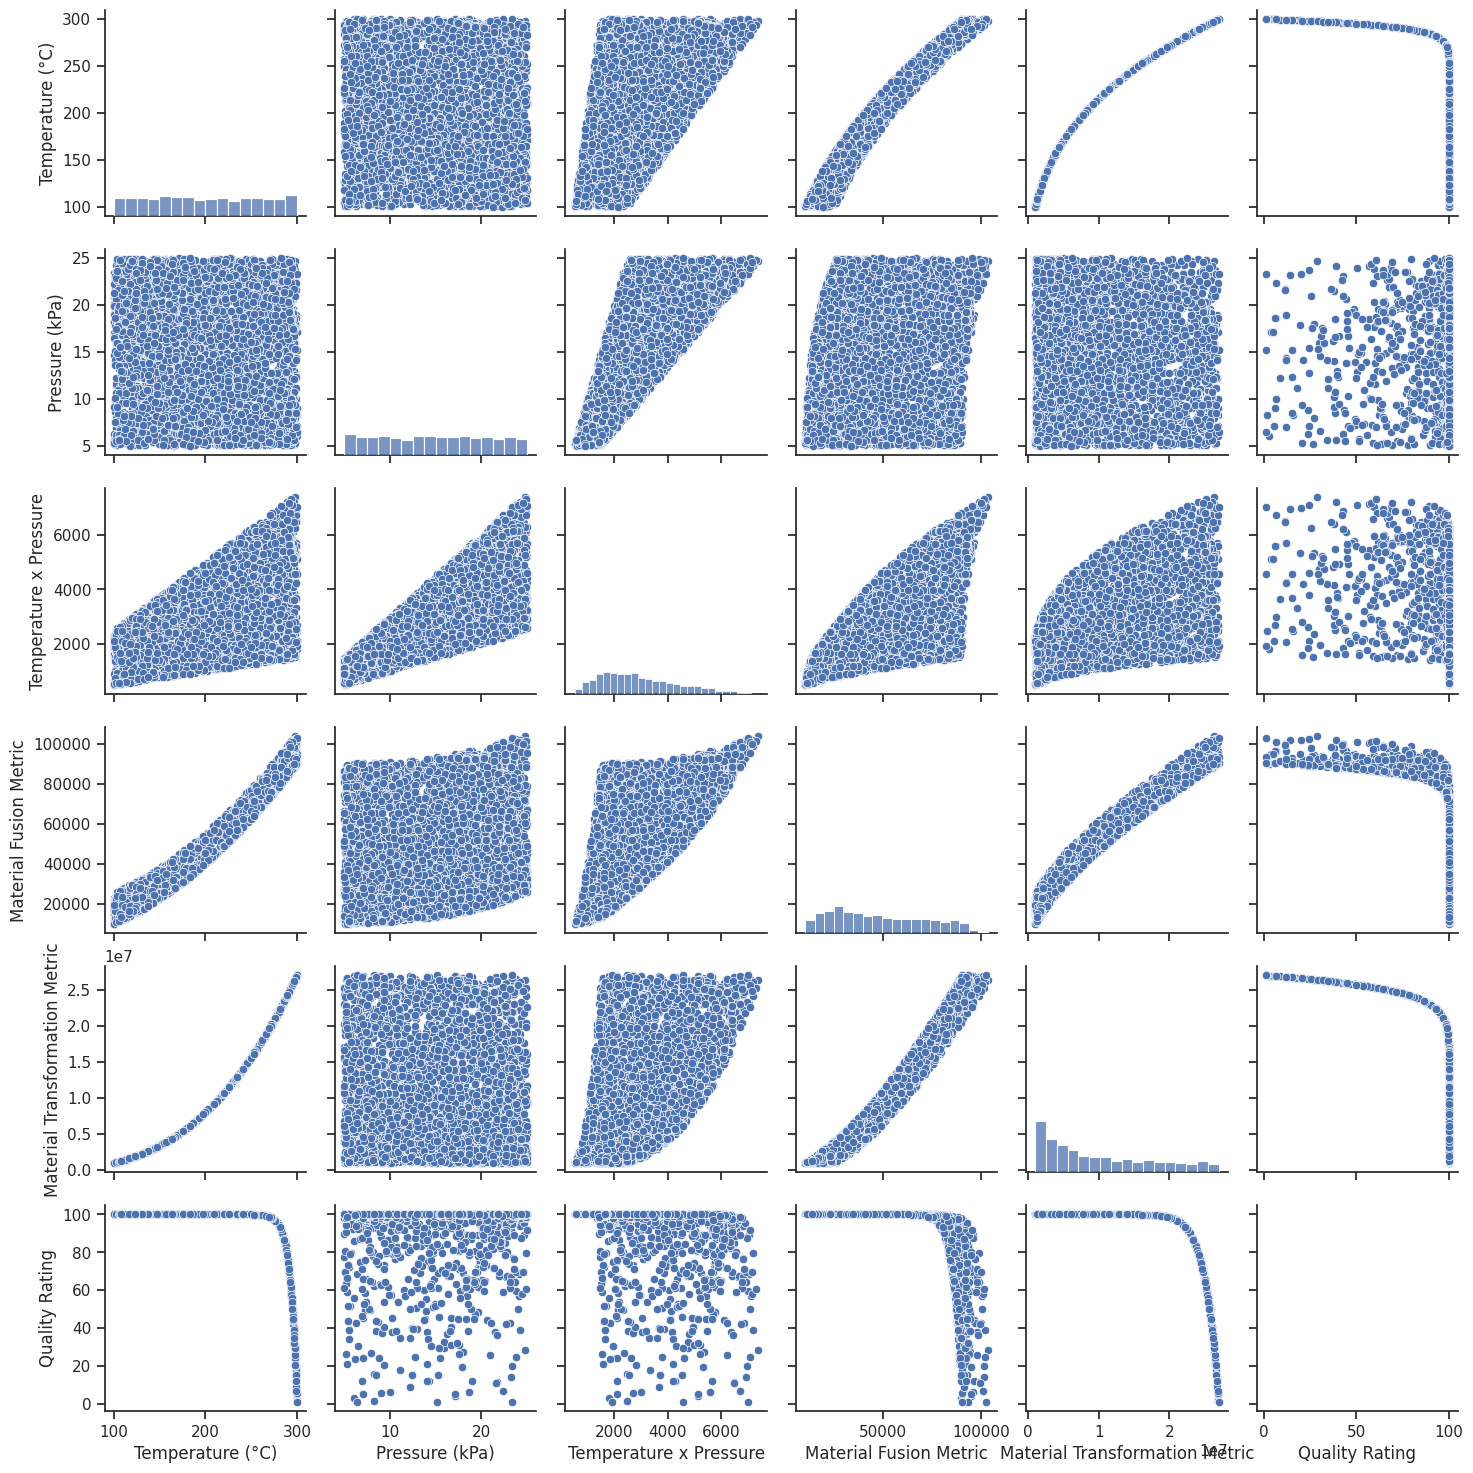

In [ ]:
# Create pairplots to visualize relationships between numerical variables
sns.set(style="ticks")
print(f"\n{bold}Pairplots:{reset}")
print("--------------------------------------------------")
print("Pairplots are used to visualize relationships between numerical variables.")
print("Each plot compares two variables, and the diagonal displays histograms.")
sns.pairplot(man_df, vars=['Temperature (°C)', 'Pressure (kPa)', 'Temperature x Pressure',
                      'Material Fusion Metric', 'Material Transformation Metric', 'Quality Rating'])
plt.show()




Correlation Heatmap:
--------------------------------------------------
A correlation heatmap displays the relationships (correlations) between variables.
Values close to 1 or -1 indicate strong correlations.
Values close to 0 indicate weak or no correlations.


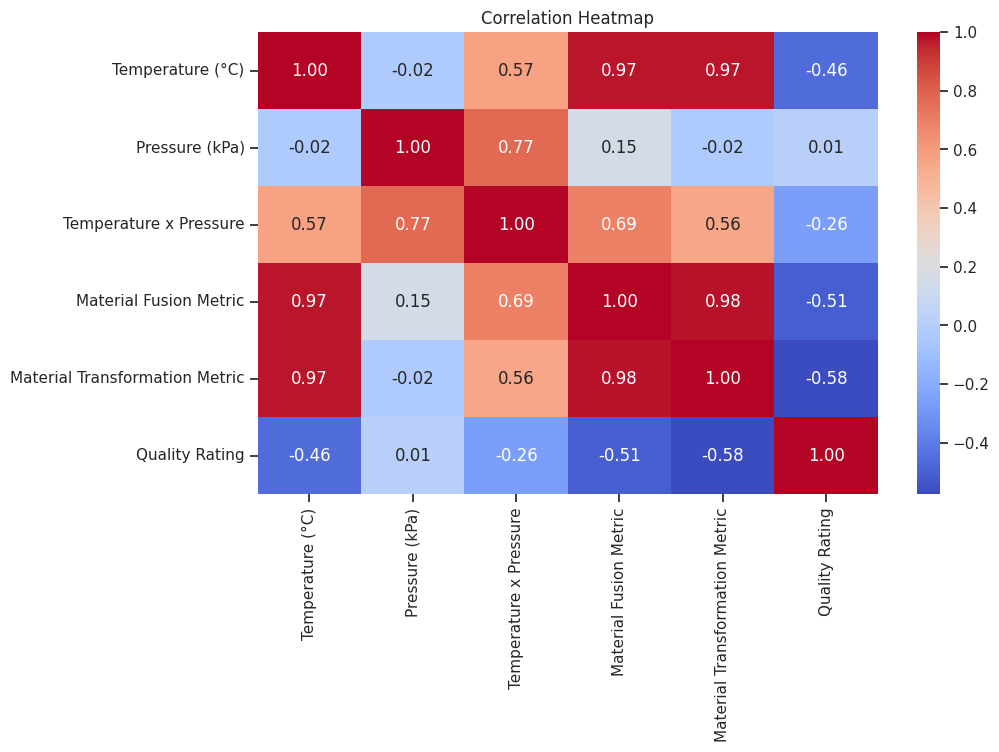

In [ ]:
# Create correlation matrix and heatmap to visualize correlations
correlation_matrix = man_df.corr()
print(f"\n{bold}Correlation Heatmap:{reset}")
print("--------------------------------------------------")
print("A correlation heatmap displays the relationships (correlations) between variables.")
print("Values close to 1 or -1 indicate strong correlations.")
print("Values close to 0 indicate weak or no correlations.")
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


Data Distribution Plots:
--------------------------------------------------
Data distribution plots, such as histograms, help visualize the distribution of individual numerical columns.
These plots can reveal the data's skewness and central tendencies.


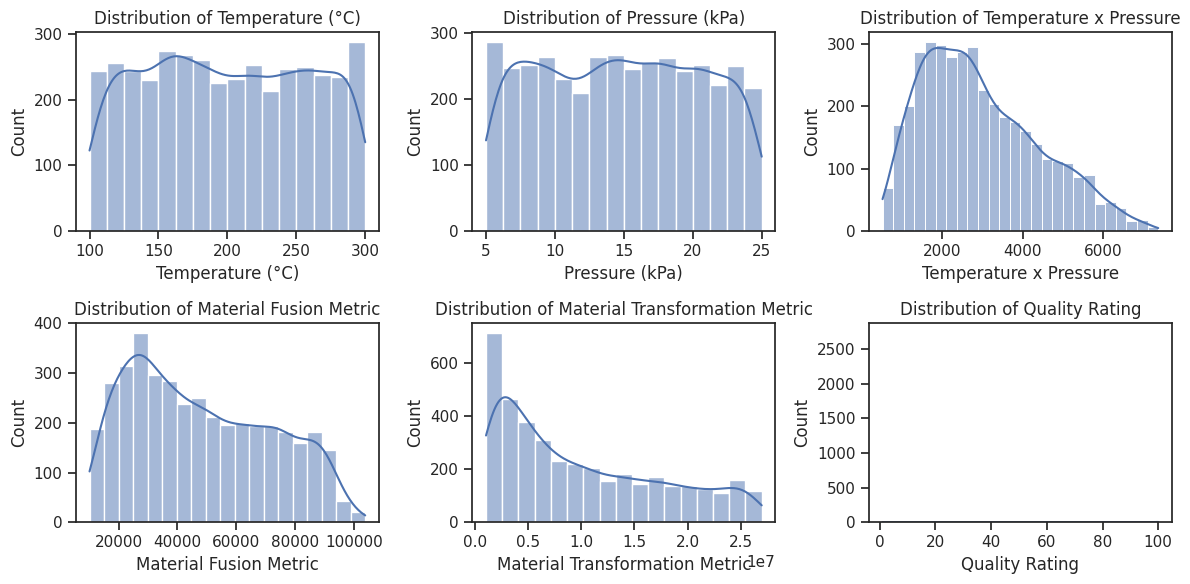


Box Plots:
--------------------------------------------------
Box plots provide a way to visualize the spread and presence of outliers in numerical columns.


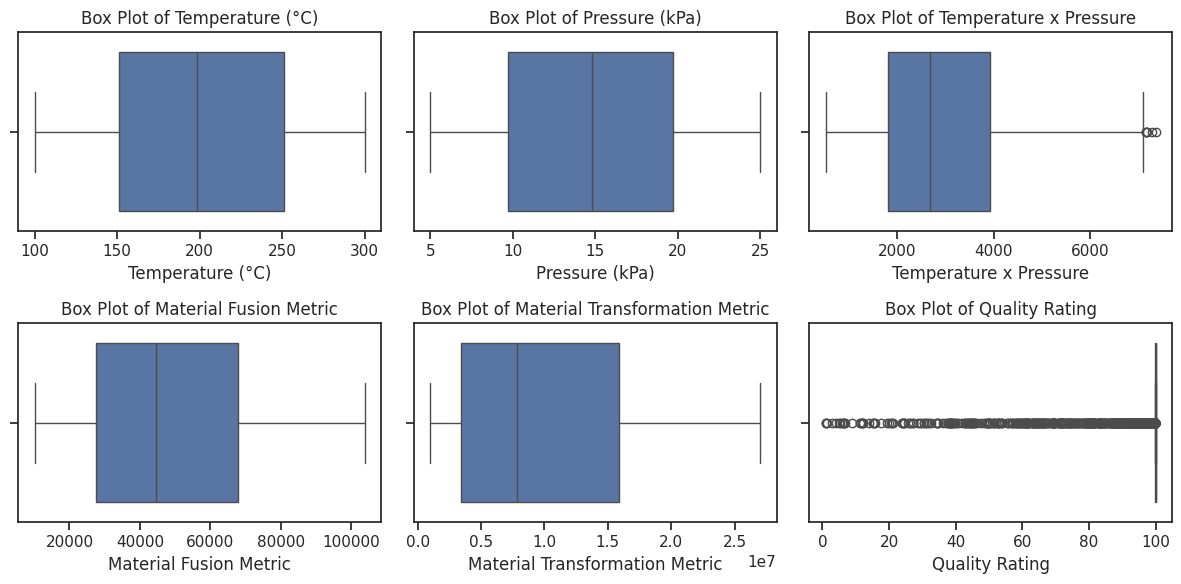

In [ ]:
# Data Distribution Plots for numerical columns
print(f"\n{bold}Data Distribution Plots:{reset}")
print("--------------------------------------------------")
print("Data distribution plots, such as histograms, help visualize the distribution of individual numerical columns.")
print("These plots can reveal the data's skewness and central tendencies.")
plt.figure(figsize=(12, 6))
numerical_columns = man_df.columns
for i, col in enumerate(numerical_columns):
    plt.subplot(2, 3, i + 1)
    sns.histplot(man_df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Box Plots for numerical columns
print(f"\n{bold}Box Plots:{reset}")
print("--------------------------------------------------")
print("Box plots provide a way to visualize the spread and presence of outliers in numerical columns.")
plt.figure(figsize=(12, 6))
for i, col in enumerate(numerical_columns):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

* Perform polynomial regression using sklearn and polyfit


In [ ]:
man_df.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [ ]:
man_df.columns


Index(['Temperature (°C)', 'Pressure (kPa)', 'Temperature x Pressure',
       'Material Fusion Metric', 'Material Transformation Metric',
       'Quality Rating'],
      dtype='object')

In [ ]:
# Rename columns
man_df.columns = ['Temperature', 'Pressure', 'TempXPress','MFM','MTM','Quality_rate' ]
man_df.head()

,Temperature,Pressure,TempXPress,MFM,MTM,Quality_rate
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [ ]:
X = man_df.drop(['Quality_rate'],axis = 1)
y = man_df['Quality_rate']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

In [ ]:


# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize dictionaries to store the best polynomial degree for each column
best_degrees = {}

# Initialize dictionaries to store the MSE values for each degree
mse_values = {}

# Loop through each column and find the best polynomial degree
for column in X.columns:
    best_degree = 1  # Initialize the best degree to 1
    best_mse = float('inf')  # Initialize the best MSE to infinity
    degrees = list(range(1, 30))  # Degrees from 1 to 10
    mse_list = []  # List to store MSE values for each degree

    for degree in degrees:
        # Create polynomial features
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train[[column]])
        X_test_poly = poly.transform(X_test[[column]])

        # Fit a linear regression model
        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        # Make predictions on the test set
        y_pred = model.predict(X_test_poly)

        # Calculate mean squared error (MSE)
        mse = mean_squared_error(y_test, y_pred)

        # Append MSE to the list
        mse_list.append(mse)

        # Update best_degree if this degree has a lower MSE
        if mse < best_mse:
            best_mse = mse
            best_degree = degree

    # Store the best degree for this column in the dictionary
    best_degrees[column] = best_degree

    # Store the MSE values for this column in the dictionary
    mse_values[column] = mse_list

# Print explanations for the best degrees for each column
for column, degree in best_degrees.items():
    print(f"The best polynomial degree for {column} is \033[91m{degree}\033[0m. This degree provides the best trade-off between complexity and accuracy for modeling the relationship between the column and the quality rating.")
    print("\n")

The best polynomial degree for Temperature is 29. This degree provides the best trade-off between complexity and accuracy for modeling the relationship between the column and the quality rating.


The best polynomial degree for Pressure is 3. This degree provides the best trade-off between complexity and accuracy for modeling the relationship between the column and the quality rating.


The best polynomial degree for TempXPress is 9. This degree provides the best trade-off between complexity and accuracy for modeling the relationship between the column and the quality rating.


The best polynomial degree for MFM is 5. This degree provides the best trade-off between complexity and accuracy for modeling the relationship between the column and the quality rating.


The best polynomial degree for MTM is 15. This degree provides the best trade-off between complexity and accuracy for modeling the relationship between the column and the quality rating.




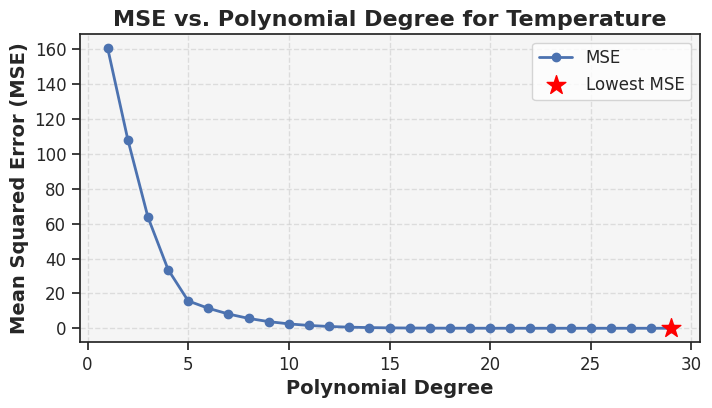

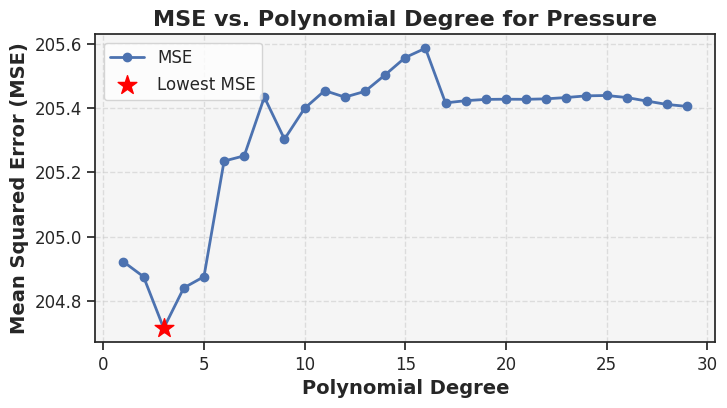

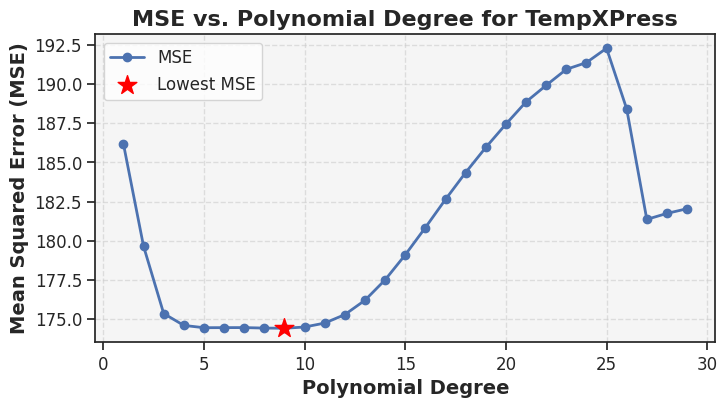

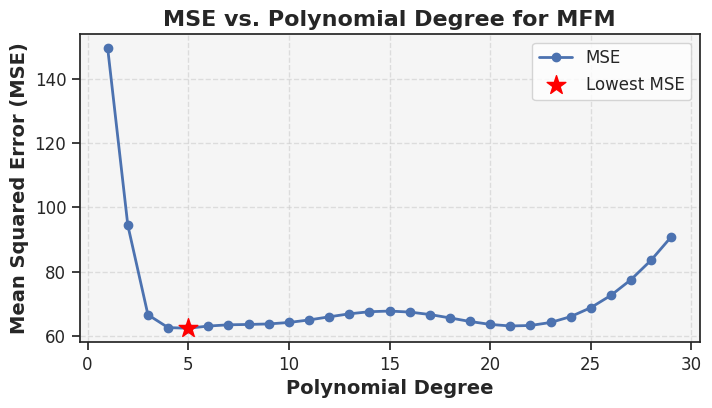

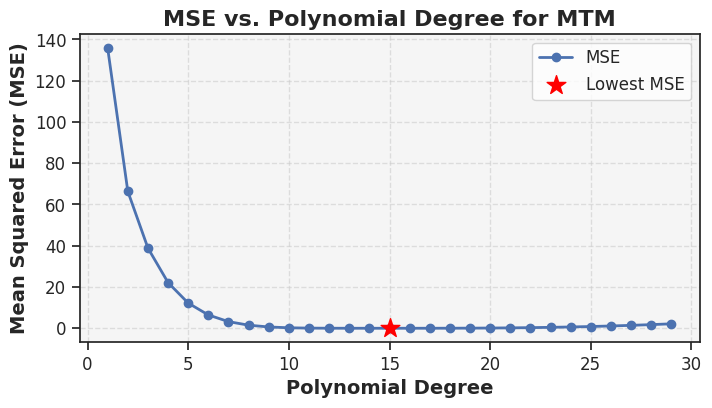

In [ ]:
for column in X.columns:
    degrees = list(range(1, 30))
    mse_list = mse_values[column]

    plt.figure(figsize=(8, 4))

    # Plot the MSE values for different polynomial degrees
    plt.plot(degrees, mse_list, marker='o', linestyle='-', color='b', label='MSE', linewidth=2)

    # Find the index of the lowest MSE
    lowest_mse_index = np.argmin(mse_list)
    lowest_mse_degree = degrees[lowest_mse_index]
    lowest_mse = mse_list[lowest_mse_index]

    # Highlight the lowest MSE point with a red star
    plt.scatter(lowest_mse_degree, lowest_mse, color='red', marker='*', s=200, label='Lowest MSE', zorder=3)

    plt.title(f'MSE vs. Polynomial Degree for {column}', fontsize=16, fontweight='bold')
    plt.xlabel('Polynomial Degree', fontsize=14, fontweight='bold')
    plt.ylabel('Mean Squared Error (MSE)', fontsize=14, fontweight='bold')

    plt.legend(fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.6)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.set_facecolor('#F5F5F5')
    plt.show()

In [ ]:
df_train = pd.concat([y_train, X_train], axis=1, sort=True)
Temperature_train = df_train["Temperature"].values.reshape(-1,1)
Pressure_train = df_train["Pressure"].values.reshape(-1,1)
TempPress_train = df_train["TempXPress"].values.reshape(-1,1)
Fusion_train = df_train["MFM"].values.reshape(-1,1)
Transformation_train = df_train["MTM"].values.reshape(-1,1)


In [ ]:
'''
Data Extraction: Specific columns from the df_test DataFrame are selected for further processing.
These columns are chosen based on their relevance to the machine learning task at hand.

Reshaping into 2D NumPy Arrays: The selected columns are reshaped into 2D NumPy arrays.
This transformation is a fundamental step in data preparation for machine learning tasks.
It ensures that the data is in the right format to be used as input for various machine learning algorithms.
'''
df_test = pd.concat([y_test, X_test], axis=1, sort=True)
Temperature_test = df_test["Temperature"].values.reshape(-1, 1)
Pressure_test = df_test["Pressure"].values.reshape(-1, 1)
TempPress_test = df_test["TempXPress"].values.reshape(-1, 1)
Fusion_test = df_test["MFM"].values.reshape(-1, 1)
Transformation_test = df_test["MTM"].values.reshape(-1, 1)

In [ ]:
poly_features = PolynomialFeatures(degree = 29) # best_degrees["Temperature (°C)"])
Temperature_train = poly_features.fit_transform(Temperature_train)
Temperature_test  = poly_features.fit_transform(Temperature_test)

poly_features = PolynomialFeatures(degree =  3) #best_degrees["Pressure (kPa)"])
Pressure_train = poly_features.fit_transform(Pressure_train)
Pressure_test  = poly_features.fit_transform(Pressure_test)

poly_features = PolynomialFeatures(degree = 9)#best_degrees['Temperature x Pressure'])
TempPress_train = poly_features.fit_transform(TempPress_train)
TempPress_test  = poly_features.fit_transform(TempPress_test)

poly_features = PolynomialFeatures(degree  = 5)# best_degrees[ 'Material Fusion Metric'])
Fusion_train= poly_features.fit_transform(Fusion_train)
Fusion_test  = poly_features.fit_transform(Fusion_test)

poly_features = PolynomialFeatures(degree  = 15)# best_degrees["Material Transformation Metric"])
Transformation_train = poly_features.fit_transform(Transformation_train)
Transformation_test  = poly_features.fit_transform(Transformation_test)


New train and test sets are created.



In [ ]:
X_train1 = np.concatenate((Temperature_train,Pressure_train,TempPress_train,Fusion_train,Transformation_train),axis =1)
X_test1 = np.concatenate((Temperature_test, Pressure_test, TempPress_test, Fusion_test, Transformation_test), axis=1)

Element-wise Multiplication (mul function): The mul function is utilized for performing element-wise multiplication between two Pandas Series or DataFrames. In essence, it multiplies each element in one Series or DataFrame with the corresponding element in another Series or DataFrame. The result is a new Series or DataFrame with the same shape.

Cartesian Product Operations: In this specific context, the code creates several new columns (int1 to int14) in a DataFrame (named X_train and X_test). These new columns are generated by performing Cartesian product operations between pairs of existing columns. The Cartesian product involves multiplying each element in one column by each element in another column, resulting in a new column that contains the combined values.

In [ ]:
#Assuming you have a DataFrame X_train

# Cartesian product between 'Pressure (kPa)' and 'Temperature (°C)'
X_train["int1"] = X_train["Pressure"].mul(X_train["Temperature"])

# Cartesian product between 'Temperature x Pressure' and 'Temperature (°C)'
X_train["int2"] = X_train["TempXPress"].mul(X_train["Temperature"])

# Cartesian product between 'Material Fusion Metric' and 'Temperature (°C)'
X_train["int3"] = X_train["MFM"].mul(X_train["Temperature"])

# Cartesian product between 'Material Transformation Metric' and 'Pressure (kPa)'
X_train["int4"] = X_train["MFM"].mul(X_train["Pressure"])

# Cartesian product between 'Temperature x Pressure' and 'Pressure (kPa)'
X_train["int5"] = X_train["TempXPress"].mul(X_train["Pressure"])

# Cartesian product between 'Material Fusion Metric' and 'Pressure (kPa)'
X_train["int6"] = X_train["MFM"].mul(X_train["Pressure"])

# Cartesian product between 'Material Transformation Metric' and 'Temperature x Pressure'
X_train["int7"] = X_train["MTM"].mul(X_train["TempXPress"])

# Cartesian product between 'Material Fusion Metric' and 'Material Transformation Metric'
X_train["int8"] = X_train["MFM"].mul(X_train["MTM"])

# Additional Cartesian product pairs
X_train["int9"] = X_train["Pressure"].mul(X_train["MFM"])
X_train["int10"] = X_train["Pressure"].mul(X_train["MTM"])
X_train["int11"] = X_train["TempXPress"].mul(X_train["MFM"])
X_train["int12"] = X_train["TempXPress"].mul(X_train["MTM"])
X_train["int13"] = X_train["MFM"].mul(X_train["MFM"])
X_train["int14"] = X_train["MTM"].mul(X_train["MTM"])

In [ ]:
# Cartesian product between 'Pressure (kPa)' and 'Temperature (°C)'
X_test["int1"] = X_test["Pressure"].mul(X_test["Temperature"])

# Cartesian product between 'Temperature x Pressure' and 'Temperature (°C)'
X_test["int2"] = X_test["TempXPress"].mul(X_test["Temperature"])

# Cartesian product between 'Material Fusion Metric' and 'Temperature (°C)'
X_test["int3"] = X_test["MFM"].mul(X_test["Temperature"])

# Cartesian product between 'Material Transformation Metric' and 'Pressure (kPa)'
X_test["int4"] = X_test["MFM"].mul(X_test["Pressure"])

# Cartesian product between 'Temperature x Pressure' and 'Pressure (kPa)'
X_test["int5"] = X_test["TempXPress"].mul(X_test["Pressure"])

# Cartesian product between 'Material Fusion Metric' and 'Pressure (kPa)'
X_test["int6"] = X_test["MFM"].mul(X_test["Pressure"])

# Cartesian product between 'Material Transformation Metric' and 'Temperature x Pressure'
X_test["int7"] = X_test["MTM"].mul(X_test["TempXPress"])

# Cartesian product between 'Material Fusion Metric' and 'Material Transformation Metric'
X_test["int8"] = X_test["MFM"].mul(X_test["MTM"])

# Additional Cartesian product pairs
X_test["int9"] = X_test["Pressure"].mul(X_test["MFM"])
X_test["int10"] = X_test["Pressure"].mul(X_test["MTM"])
X_test["int11"] = X_test["TempXPress"].mul(X_test["MFM"])
X_test["int12"] = X_test["TempXPress"].mul(X_test["MTM"])
X_test["int13"] = X_test["MFM"].mul(X_test["MFM"])
X_test["int14"] = X_test["MTM"].mul(X_test["MTM"])

In [ ]:
X_train2 = np.array(X_train[['int1','int2','int3','int4','int5','int6','int7','int8','int9','int10','int11','int12','int13','int14']])
X_test2 = np.array(X_test[['int1','int2','int3','int4','int5','int6','int7','int8','int9','int10','int11','int12','int13','int14']])

In [ ]:
X_train1 = np.concatenate ((X_train1, X_train2), axis = 1)
X_test1 = np.concatenate ((X_test1, X_test2), axis = 1)

In [ ]:
poly_reg = LinearRegression()
poly_reg.fit(X_train1, y_train)

LinearRegression()

In [ ]:
score = poly_reg.score(X_test1, y_test)
print("R-squared score of the test:", score)

R-squared score of the test: -0.001445067485561946


In [ ]:
score = poly_reg.score(X_train1, y_train)
print("R-squared score of the train:", score)

R-squared score of the train: 0.0005558229821761573


In [ ]:
y_pred_train = poly_reg.predict(X_train1)

for i, (real_value, prediction) in enumerate(zip(y_train.iloc[:10], y_pred_train[:10])):
    print(f"Sample {i + 1} - Real Value: {real_value}, Predicted Value: {prediction}")

Sample 1 - Real Value: 99.9998950832658, Predicted Value: 96.23380733377302
Sample 2 - Real Value: 99.99999996545394, Predicted Value: 96.23642843494511
Sample 3 - Real Value: 99.99999999972384, Predicted Value: 96.23385670866047
Sample 4 - Real Value: 100.0, Predicted Value: 96.23380626496166
Sample 5 - Real Value: 100.0, Predicted Value: 96.23379983158307
Sample 6 - Real Value: 46.3670249698838, Predicted Value: 96.23406260824365
Sample 7 - Real Value: 99.9981213046946, Predicted Value: 96.58601332683291
Sample 8 - Real Value: 99.9994029171498, Predicted Value: 96.23379979622347
Sample 9 - Real Value: 100.0, Predicted Value: 96.26044786148994
Sample 10 - Real Value: 99.99999997078464, Predicted Value: 96.23380325705494


In [ ]:
y_pred_test = poly_reg.predict(X_test1)

for i, (real_value, prediction) in enumerate(zip(y_test.iloc[:10], y_pred_test[:10])):
    print(f"Sample {i + 1} - Real Value: {real_value}, Predicted Value: {prediction}")

Sample 1 - Real Value: 4.052686484307197, Predicted Value: 96.23379986732843
Sample 2 - Real Value: 98.8730359715154, Predicted Value: 97.40546373676342
Sample 3 - Real Value: 96.91493256400273, Predicted Value: 96.23381550057219
Sample 4 - Real Value: 99.9515431703238, Predicted Value: 96.23379978949096
Sample 5 - Real Value: 99.99999939463342, Predicted Value: 96.31612129305903
Sample 6 - Real Value: 99.99999801897562, Predicted Value: 96.23379978949097
Sample 7 - Real Value: 99.9999414424484, Predicted Value: 96.2337998176537
Sample 8 - Real Value: 99.99962261607838, Predicted Value: 96.2337997895079
Sample 9 - Real Value: 100.0, Predicted Value: 96.23379996355256
Sample 10 - Real Value: 59.01936688952299, Predicted Value: 96.23381574339713


* Measure the performance for each polynomial degree.


In [ ]:
rmse= []
degrees = np.arange(1,5)
min_rmse , min_value = 1e10, 0

for degree in degrees:
    poly_features = PolynomialFeatures(degree=degree)
    X_poly_train = poly_features.fit_transform(X_train)

    # Create and train a linear regression model
    model = LinearRegression()
    model.fit(X_poly_train, y_train)

    X_poly_test = poly_features.fit_transform(X_test)

    # Make predictions
    y_pred = model.predict(X_poly_test)

    # Calculate RMSE
    mse = mean_squared_error(y_test, y_pred)
    current_rmse = np.sqrt(mse)

    # Store RMSE values
    rmse.append(current_rmse)

    # Check if this is the model with the lowest RMSE
    if current_rmse < min_rmse:
        min_rmse = current_rmse
        min_degree = degree

print("RMSE values for polynomial degrees 2 to 5:", rmse)
print("Minimum RMSE:", min_rmse)
print("Degree with minimum RMSE:", min_degree)

RMSE values for polynomial degrees 2 to 5: [5.298976339194973, 1.3269886110057367, 0.7122107293503133, 0.12541821901361458]
Minimum RMSE: 0.12541821901361458
Degree with minimum RMSE: 4


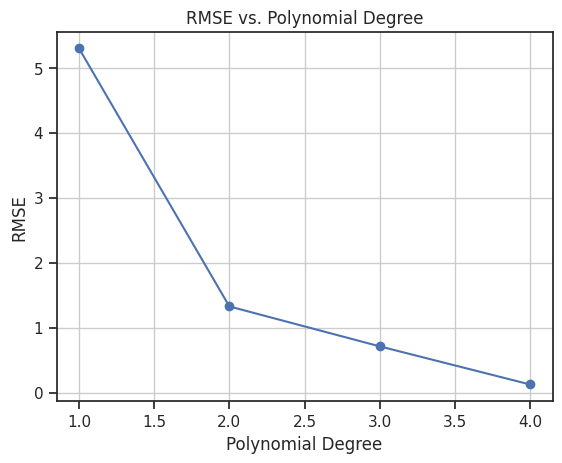

In [ ]:
plt.plot(degrees, rmse, marker='o')
plt.title('RMSE vs. Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

In [ ]:
poly_degree = PolynomialFeatures(degree = 2)
X_train_pol = poly_degree.fit_transform(X_train)
X_test_pol = poly_degree.transform(X_test)

* Plot the performance of the model for each polynomial degree.

In [ ]:
PR = LinearRegression()
PR.fit(X_train_pol, y_train)
y_pred_PR = PR.predict(X_test_pol)
mse_PR = mean_squared_error(y_test, y_pred_PR)# Calculate the Mean Squared Error (MSE)
# Print the scores for Polynomial Regression
print(f"Polynomial Regression MSE: {mse_PR}")
print(f"Polynomial Regression Score on test: {PR.score(X_test_pol, y_test)}")
print(f"Polynomial Regression Score on train: {PR.score(X_train_pol, y_train)}")
print("\n")
LR = LinearRegression()
LR.fit(X_train, y_train)
y_pred_LR = LR.predict(X_test)
mse_LR = mean_squared_error(y_test, y_pred_LR)# Calculate the Mean Squared Error (MSE)
# Print the scores for Linear Regression
print(f"Linear Regression MSE: {mse_LR}")
print(f"Linear Regression Score on test:{ LR.score(X_test, y_test)}")
print(f"Linear Regression Score on train:{ LR.score(X_train, y_train)}")


Polynomial Regression MSE: 1.7608987737389346
Polynomial Regression Score on test: 0.9913745112096375
Polynomial Regression Score on train: 0.9909496906689048


Linear Regression MSE: 27.835678360121634
Linear Regression Score on test:0.8636512585231886
Linear Regression Score on train:0.8607194017782437


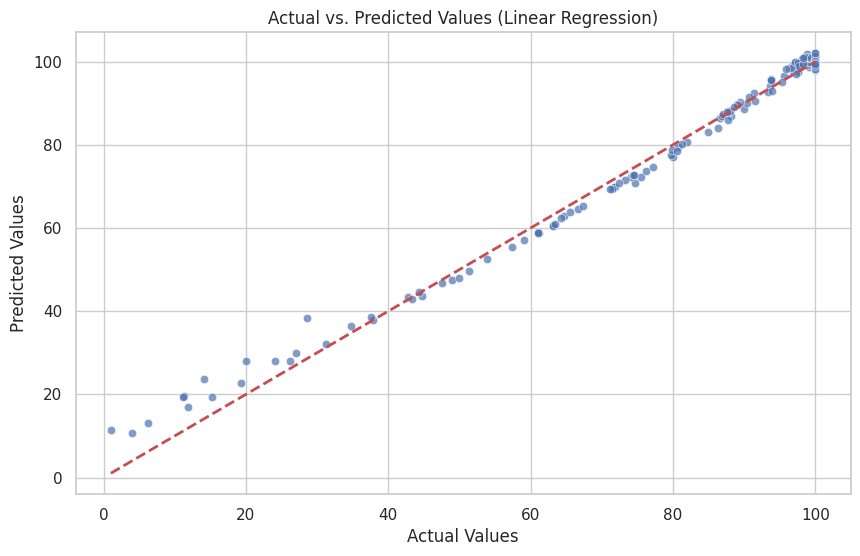

In [ ]:
# Create a scatterplot of actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.scatterplot(x=y_test, y=y_pred_PR, color='b', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (Linear Regression)")
plt.show()

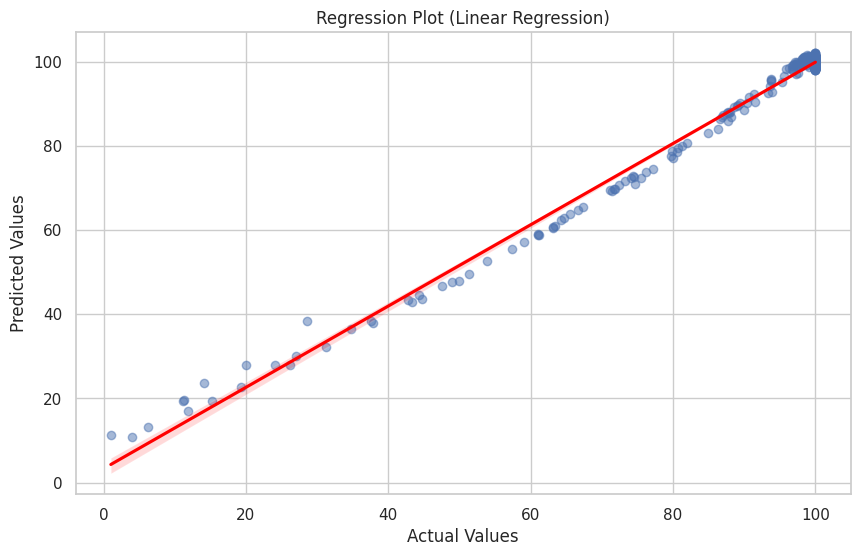

In [ ]:
# Create a regression plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.regplot(x=y_test, y=y_pred_PR, scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Regression Plot (Linear Regression)")
plt.show()

Text(0.5, 1.0, 'Residuals vs. Fitted Values')

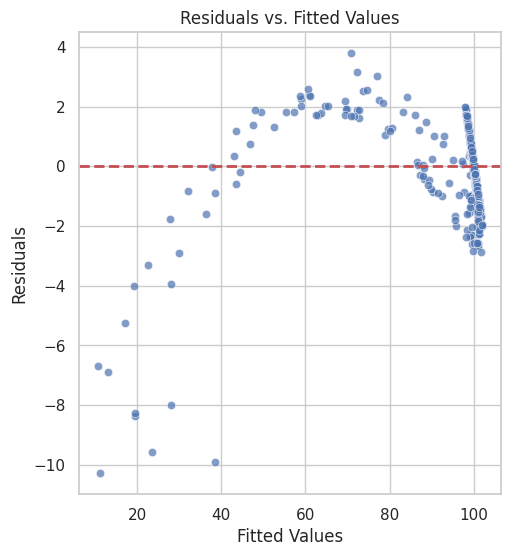

In [ ]:
# Create residual plots
plt.figure(figsize=(12, 6))
# Residuals vs. Fitted Values
plt.subplot(1, 2, 1)
sns.set(style="whitegrid")
sns.scatterplot(x=y_pred_PR, y=y_test-y_pred_PR, color='b', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")

#### 4.3 Logistic Regression

* Choose your own dataset


##### **About the Dataset**

The [RT-IoT2022](https://archive.ics.uci.edu/dataset/942/rt-iot2022), a proprietary dataset derived from a real-time IoT infrastructure, is introduced as a comprehensive resource integrating a diverse range of IoT devices and sophisticated network attack methodologies. This dataset encompasses both normal and adversarial network behaviours, providing a general representation of real-world scenarios. Incorporating data from IoT devices such as ThingSpeak-LED, Wipro-Bulb, and MQTT-Temp, as well as simulated attack scenarios involving Brute-Force SSH attacks, DDoS attacks using Hping and Slowloris, and Nmap patterns, RT-IoT2022 offers a detailed perspective on the complex nature of network traffic. The bidirectional attributes of network traffic are meticulously captured using the Zeek network monitoring tool and the Flowmeter plugin. Researchers can leverage the RT-IoT2022 dataset to advance the capabilities of Intrusion Detection Systems (IDS), fostering the development of robust and adaptive security solutions for real-time IoT networks.

* Import the dataset


In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
rt_iot2022 = fetch_ucirepo(id=942)

# data (as pandas dataframes)
X = rt_iot2022.data.features
y = rt_iot2022.data.targets

# metadata
print(rt_iot2022.metadata)

# variable information
print(rt_iot2022.variables)


{'uci_id': 942, 'name': 'RT-IoT2022 ', 'repository_url': 'https://archive.ics.uci.edu/dataset/942/rt-iot2022', 'data_url': 'https://archive.ics.uci.edu/static/public/942/data.csv', 'abstract': 'The RT-IoT2022, a proprietary dataset derived from a real-time IoT infrastructure, is introduced as a comprehensive resource integrating a diverse range of IoT devices and sophisticated network attack methodologies. This dataset encompasses both normal and adversarial network behaviours, providing a general representation of real-world scenarios.\nIncorporating data from IoT devices such as ThingSpeak-LED, Wipro-Bulb, and MQTT-Temp, as well as simulated attack scenarios involving Brute-Force SSH attacks, DDoS attacks using Hping and Slowloris, and Nmap patterns, RT-IoT2022 offers a detailed perspective on the complex nature of network traffic. The bidirectional attributes of network traffic are meticulously captured using the Zeek network monitoring tool and the Flowmeter plugin. Researchers can

* Determine the number of datapoints, columns and data types


In [ ]:
df = pd.concat([X,y],axis = 1)
print(f"M = {df.shape[0]} \tN = {df.shape[1]}")
df.head()

M = 123117 	N = 84


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502,MQTT_Publish


In [ ]:
#the number of datapoints
print(df.shape[0])

#the column names
print(df.columns.tolist())

#the data types for each column
print(df.dtypes)

123117
['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fw

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 84 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id.orig_p                 123117 non-null  int64  
 1   id.resp_p                 123117 non-null  int64  
 2   proto                     123117 non-null  object 
 3   service                   123117 non-null  object 
 4   flow_duration             123117 non-null  float64
 5   fwd_pkts_tot              123117 non-null  int64  
 6   bwd_pkts_tot              123117 non-null  int64  
 7   fwd_data_pkts_tot         123117 non-null  int64  
 8   bwd_data_pkts_tot         123117 non-null  int64  
 9   fwd_pkts_per_sec          123117 non-null  float64
 10  bwd_pkts_per_sec          123117 non-null  float64
 11  flow_pkts_per_sec         123117 non-null  float64
 12  down_up_ratio             123117 non-null  float64
 13  fwd_header_size_tot       123117 non-null  i

* Remove unneccesary columns


In [ ]:
# dropping unnecessary columns
columns_to_drop = ['id.orig_p', 'id.resp_p', 'proto']  #  columns to be deleted
df = df.drop(['id.orig_p', 'id.resp_p'],axis = 1)
df

,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,tcp,mqtt,32.011598,9,5,3,3,0.281148,0.156193,0.437341,...,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish
1,tcp,mqtt,31.883584,9,5,3,3,0.282277,0.156821,0.439097,...,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish
2,tcp,mqtt,32.124053,9,5,3,3,0.280164,0.155647,0.435811,...,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish
3,tcp,mqtt,31.961063,9,5,3,3,0.281593,0.156440,0.438033,...,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish
4,tcp,mqtt,31.902362,9,5,3,3,0.282111,0.156728,0.438839,...,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502,MQTT_Publish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,tcp,-,0.000006,1,1,0,0,167772.160000,167772.160000,335544.320000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123113,tcp,-,0.000007,1,1,0,0,144631.172400,144631.172400,289262.344800,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123114,tcp,-,0.000006,1,1,0,0,167772.160000,167772.160000,335544.320000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123115,tcp,-,0.000006,1,1,0,0,167772.160000,167772.160000,335544.320000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN


* Do data cleaning such as removing empty values(NaN), replacing missing data .


* Perform descriptive statistics such as mean, median and mode


In [ ]:
df.describe()

,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
count,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,1.231170e+05,1.231170e+05,1.231170e+05,123117.000000,123117.000000,...,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,123117.000000,123117.000000,123117.000000
mean,3.809566,2.268826,1.909509,1.471218,0.820260,3.518063e+05,3.517620e+05,7.035683e+05,0.854571,53.892379,...,1.481354e+05,2.353599e+04,1.616655e+06,1.701956e+06,3.517644e+06,1.664985e+06,4.550183e+04,6118.905123,2739.776018,751.647514
std,130.005408,22.336565,33.018311,19.635196,32.293948,3.707645e+05,3.708015e+05,7.415634e+05,0.337640,393.027195,...,1.613007e+06,1.477935e+06,8.809396e+06,9.252337e+06,1.229508e+08,9.007064e+06,1.091361e+06,18716.313861,10018.848534,6310.183843
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000001,1.000000,1.000000,1.000000,0.000000,7.454354e+01,7.288927e+01,1.490871e+02,1.000000,20.000000,...,9.536740e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
50%,0.000004,1.000000,1.000000,1.000000,0.000000,2.467238e+05,2.467238e+05,4.934475e+05,1.000000,20.000000,...,4.053116e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
75%,0.000005,1.000000,1.000000,1.000000,0.000000,5.242880e+05,5.242880e+05,1.048576e+06,1.000000,20.000000,...,5.006790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
max,21728.335580,4345.000000,10112.000000,4345.000000,10105.000000,1.048576e+06,1.048576e+06,2.097152e+06,6.087899,69296.000000,...,4.374931e+08,4.774862e+08,3.000000e+08,3.000000e+08,2.096777e+10,3.000000e+08,1.208029e+08,65535.000000,65535.000000,65535.000000


* Perform data visualization


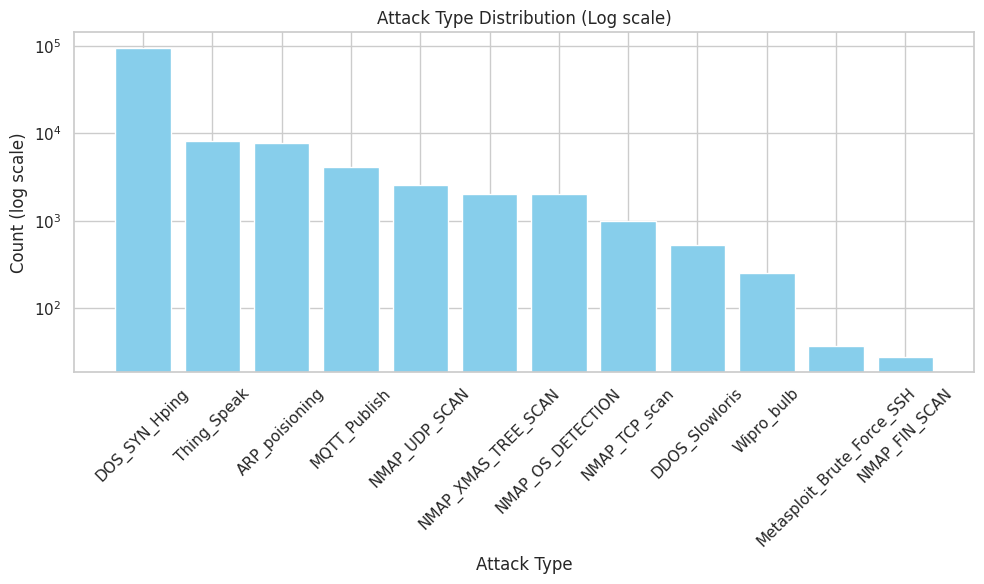

In [ ]:
attck_type_counts  = df['Attack_type'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(np.arange(len(attck_type_counts)), attck_type_counts.values, color= 'skyblue')
plt.title('Attack Type Distribution (Log scale)')
plt.xlabel('Attack Type')
plt.ylabel('Count (log scale)')
plt.xticks(np.arange(len(attck_type_counts)),attck_type_counts.index, rotation = 45)
plt.yscale('log') #Set y-axis to Logarithmic Scale
plt.tight_layout()
plt.show()

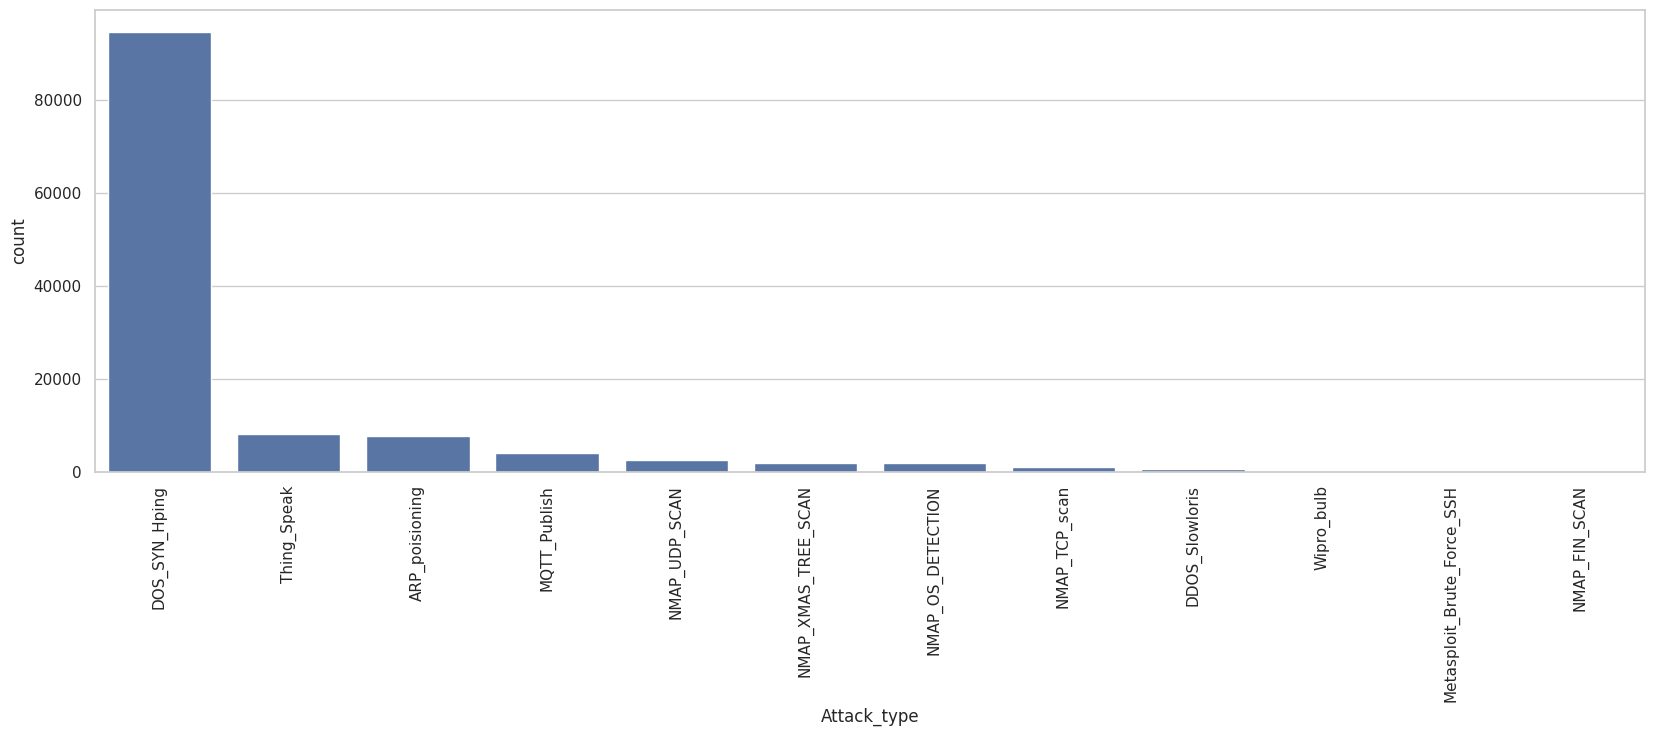

In [ ]:
figure = plt.subplots(figsize = (20,6))
sns.countplot(data = df, x = df['Attack_type'], order = df['Attack_type'].value_counts().index)
plt.xticks(rotation = 90)
plt.show()

* Solve classification problem using Logistic Regression


In [ ]:
# Select features and target variable for classification
X = df.drop(columns=['Attack_Type'])  # Drop the target column
y = df['Attack_Type']  # Target column

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the logistic regression model
logreg = LogisticRegression(max_iter=1000)

In [ ]:
logreg.fit(X_train, y_train)

In [ ]:
y_pred = logreg.predict(X_test)

* Evaluate the model using classification report, accuracy and confusion matrix

In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

## 5. Summary, Conclusions and Lessons Learned

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*

***Disclaimer***

*Contents of this Notebook are based on Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow 3rd Edition by Aurelien Geron.*
*A copy of the complete text can be obtained here: https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/*